# 🧠 The Knowledge Graph Revolution
## The Scaffold for Truth in the Age of LLM Hallucinations

---

> *"The Semantic Web is not a separate Web but an extension of the current one, in which information is given well-defined meaning, better enabling computers and people to work in cooperation."*
> — **Tim Berners-Lee, 2001**

Knowledge Graphs aren't just "nodes and edges." They are the **long-term memory** and **reasoning engine** for the next generation of AI. In a world where LLMs hallucinate with confidence, KGs provide the **verifiable scaffold of truth** that grounds AI in reality.

### What You'll Build in This Notebook

| Section | What You'll Learn |
|---|---|
| **1. The Genesis** | From Semantic Web to Google's Brain — the "Strings to Things" revolution |
| **2. The Mechanics** | Triples, Ontologies, and Logical Inference — the DNA of knowledge |
| **3. State-of-the-Art** | GraphRAG, Neuro-Symbolic AI, and Self-Evolving Graphs |
| **4. Drug Discovery** | AI reasons over a biomedical KG to find hidden drug repurposing paths |
| **5. Fraud Detection** | Detecting circular money laundering through graph topology |
| **6. Virtual Software Engineer** | A KG as the "operating system" for an AI agent's unified context |
| **7. GraphRAG in Action** | Building a GraphRAG pipeline with LLMs + Knowledge Graphs |

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from typing import List, Tuple, Dict, Set, Optional
import json
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 100

print("✅ All imports ready. Let's build some Knowledge Graphs!")

✅ All imports ready. Let's build some Knowledge Graphs!


In [2]:
!pip install -q networkx matplotlib pyvis rdflib langchain-openai langchain-anthropic langchain-community


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---

# Part 1: The Genesis — From "Strings to Things"

The history of Knowledge Graphs is the story of humanity's quest to make machines **understand meaning**, not just match patterns.

### The Timeline

| Year | Event | Significance |
|------|-------|-------------|
| **1960s** | Semantic Networks (Quillian) | First attempt to represent meaning as a graph of concepts |
| **1998** | RDF Specification (W3C) | A universal language for describing relationships |
| **2001** | Tim Berners-Lee's Semantic Web | The dream: a machine-readable internet where data links to data |
| **2006** | DBpedia / Freebase | Wikipedia's knowledge, structured as a graph — millions of triples |
| **2012** | Google Knowledge Graph | *"Things, not strings."* Search transforms from keyword matching to entity understanding |
| **2013** | Wikidata launches | The open, collaborative knowledge base — 100M+ items today |
| **2016** | LinkedIn Economic Graph | 1B+ members, 67M companies, 131K schools — all connected |
| **2020** | Uber's Logistics Graph | Real-time routing, pricing, and supply-demand matching through graph relationships |
| **2023-26** | GraphRAG Revolution | LLMs + KGs = Grounded reasoning. Microsoft's GraphRAG paper changes the game |

### The Key Insight

Before 2012, searching for **"Taj Mahal"** meant matching those characters against web pages. You'd get results about the monument, the musician, and the casino — all jumbled together.

After the Knowledge Graph, Google *understood* that "Taj Mahal" is an **entity** — a marble mausoleum in Agra, India, built by Mughal Emperor Shah Jahan in 1632. It has **relationships**: located_in → Agra, built_by → Shah Jahan, architectural_style → Mughal Architecture.

**That's the revolution: from matching strings to understanding things.**

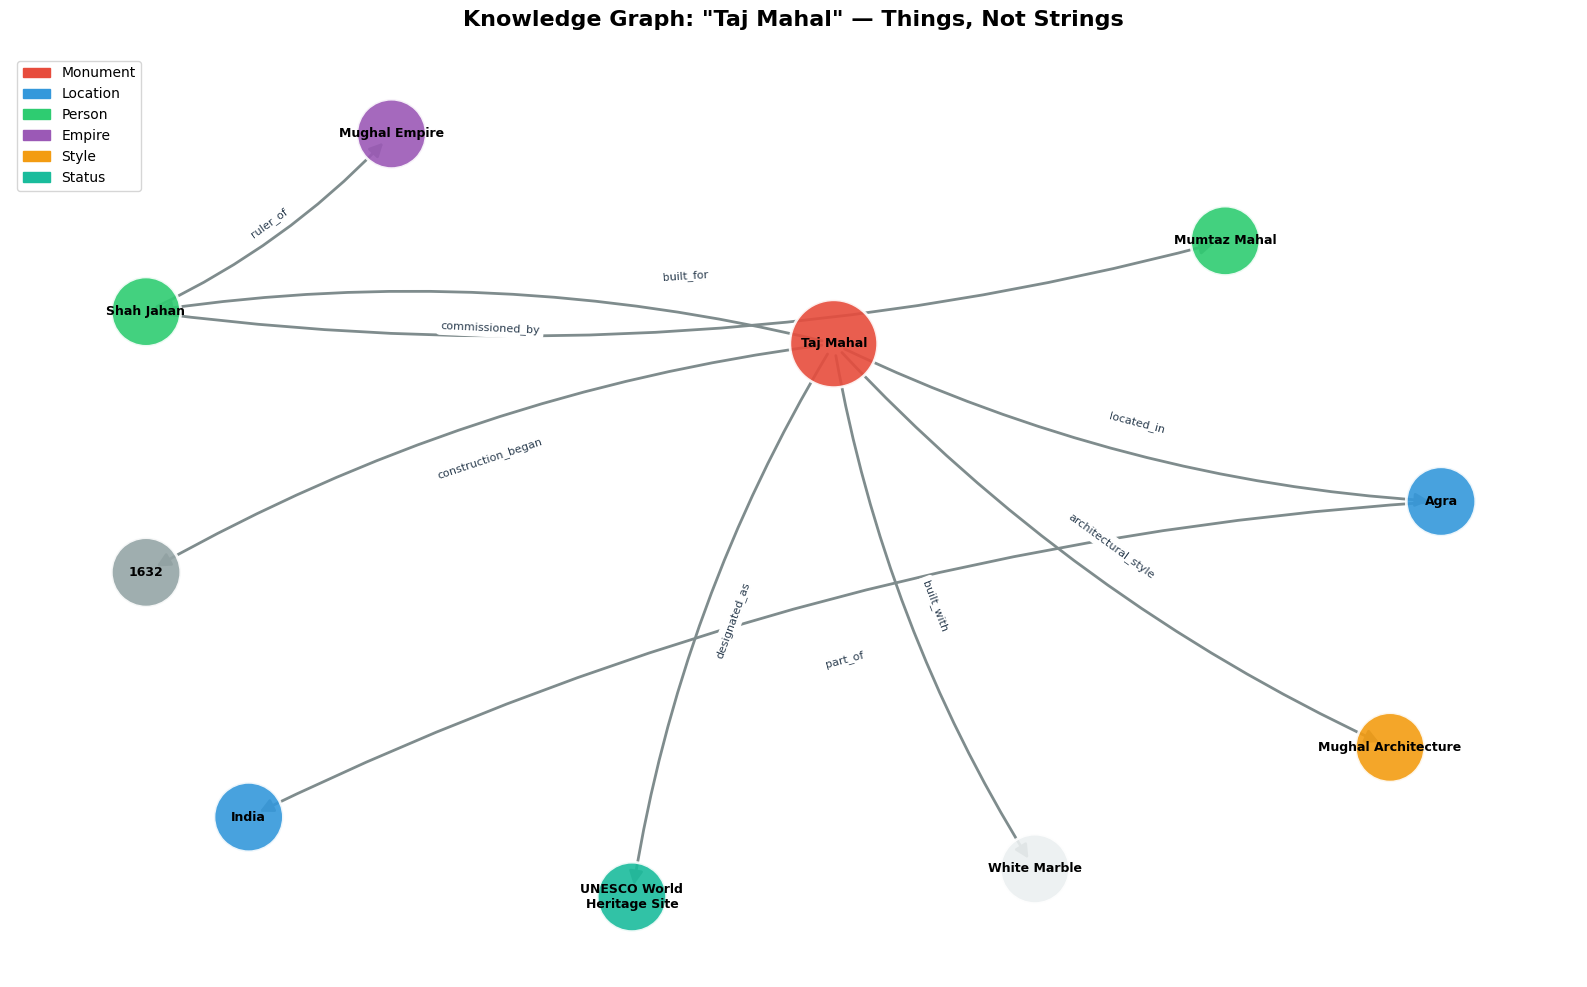


💡 KEY INSIGHT: A search engine with this graph doesn't just match 'Taj Mahal' —
   it UNDERSTANDS it's a monument, in Agra, built by Shah Jahan, in Mughal style.
   That's the power of Knowledge Graphs.


In [15]:
# --- Visualize: "Strings to Things" — The Taj Mahal Example ---
# Before KGs: keyword matching. After KGs: entity understanding.

G_taj = nx.DiGraph()

entities = {
    "Taj Mahal":        {"type": "Monument", "color": "#e74c3c"},
    "Agra":             {"type": "City", "color": "#3498db"},
    "India":            {"type": "Country", "color": "#3498db"},
    "Shah Jahan":       {"type": "Person", "color": "#2ecc71"},
    "Mumtaz Mahal":     {"type": "Person", "color": "#2ecc71"},
    "Mughal Empire":    {"type": "Empire", "color": "#9b59b6"},
    "Mughal Architecture": {"type": "Style", "color": "#f39c12"},
    "UNESCO World\nHeritage Site": {"type": "Status", "color": "#1abc9c"},
    "1632":             {"type": "Year", "color": "#95a5a6"},
    "White Marble":     {"type": "Material", "color": "#ecf0f1"},
}

for entity, attrs in entities.items():
    G_taj.add_node(entity, **attrs)

relationships = [
    ("Taj Mahal", "Agra", "located_in"),
    ("Agra", "India", "part_of"),
    ("Taj Mahal", "Shah Jahan", "commissioned_by"),
    ("Shah Jahan", "Mumtaz Mahal", "built_for"),
    ("Shah Jahan", "Mughal Empire", "ruler_of"),
    ("Taj Mahal", "Mughal Architecture", "architectural_style"),
    ("Taj Mahal", "UNESCO World\nHeritage Site", "designated_as"),
    ("Taj Mahal", "1632", "construction_began"),
    ("Taj Mahal", "White Marble", "built_with"),
]

for s, o, p in relationships:
    G_taj.add_edge(s, o, relation=p)

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
pos = nx.spring_layout(G_taj, seed=42, k=2.5)

node_colors = [entities[n]["color"] for n in G_taj.nodes()]
node_sizes = [4000 if n == "Taj Mahal" else 2500 for n in G_taj.nodes()]

nx.draw_networkx_nodes(G_taj, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.9, edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(G_taj, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G_taj, pos, edge_color="#7f8c8d", arrows=True,
                        arrowsize=20, width=2, connectionstyle="arc3,rad=0.1", ax=ax)

edge_labels = {(s, o): p for s, o, p in relationships}
nx.draw_networkx_edge_labels(G_taj, pos, edge_labels=edge_labels,
                              font_size=8, font_color="#2c3e50", ax=ax)

legend_items = [
    mpatches.Patch(color="#e74c3c", label="Monument"),
    mpatches.Patch(color="#3498db", label="Location"),
    mpatches.Patch(color="#2ecc71", label="Person"),
    mpatches.Patch(color="#9b59b6", label="Empire"),
    mpatches.Patch(color="#f39c12", label="Style"),
    mpatches.Patch(color="#1abc9c", label="Status"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=10)

ax.set_title('Knowledge Graph: "Taj Mahal" — Things, Not Strings',
             fontsize=16, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: A search engine with this graph doesn't just match 'Taj Mahal' —")
print("   it UNDERSTANDS it's a monument, in Agra, built by Shah Jahan, in Mughal style.")
print("   That's the power of Knowledge Graphs.")

---

# Part 2: The "Mind-Blowing" Mechanics

## 2.1 The Triple: The Atom of Knowledge

Everything in a Knowledge Graph is stored as a **Triple**:

```
(Subject) —[Predicate]→ (Object)
```

Examples:
- `(Einstein) —[born_in]→ (Ulm)`
- `(Einstein) —[developed]→ (Theory of Relativity)`
- `(Theory of Relativity) —[published_in]→ (1905)`

A triple is the simplest possible statement of fact. Stack enough of them together, and you get a **web of interconnected knowledge** that machines can traverse, query, and reason over.

## 2.2 Schema as DNA: Ontologies

An **Ontology** defines the *rules* of the world your graph represents. It's the DNA — the blueprint that constrains what can exist and how things connect.

Think of it as a **type system for reality:**
- A `Person` can `work_at` a `Company`
- A `Company` can `headquartered_in` a `City`
- But a `City` cannot `work_at` a `Person` ← The ontology prevents nonsense

## 2.3 Logical Reasoning: Discovering Hidden Facts

The real magic: a KG can **infer facts that were never explicitly stated** by traversing paths and applying logical rules.

In [16]:
# --- 2.1 Building Triples with RDF ---
# RDF (Resource Description Framework) is the standard language for KG triples

from rdflib import Graph as RDFGraph, Namespace, Literal, URIRef
from rdflib.namespace import RDF, RDFS, OWL, XSD

EX = Namespace("http://example.org/")

rdf_graph = RDFGraph()
rdf_graph.bind("ex", EX)

triples = [
    (EX.Einstein,           RDF.type,           EX.Person),
    (EX.Einstein,           EX.born_in,         EX.Ulm),
    (EX.Einstein,           EX.developed,       EX.TheoryOfRelativity),
    (EX.Einstein,           EX.won,             EX.NobelPrize1921),
    (EX.TheoryOfRelativity, RDF.type,           EX.ScientificTheory),
    (EX.TheoryOfRelativity, EX.published_year,  Literal(1905, datatype=XSD.integer)),
    (EX.Ulm,                RDF.type,           EX.City),
    (EX.Ulm,                EX.located_in,      EX.Germany),
    (EX.Germany,            RDF.type,           EX.Country),
    (EX.NobelPrize1921,     RDF.type,           EX.Award),
    (EX.NobelPrize1921,     EX.field,           EX.Physics),
]

for triple in triples:
    rdf_graph.add(triple)

print("=== RDF Triples (Turtle Format) ===\n")
print(rdf_graph.serialize(format="turtle"))
print(f"\n📊 Total triples in graph: {len(rdf_graph)}")

=== RDF Triples (Turtle Format) ===

@prefix ex: <http://example.org/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:Einstein a ex:Person ;
    ex:born_in ex:Ulm ;
    ex:developed ex:TheoryOfRelativity ;
    ex:won ex:NobelPrize1921 .

ex:Germany a ex:Country .

ex:NobelPrize1921 a ex:Award ;
    ex:field ex:Physics .

ex:TheoryOfRelativity a ex:ScientificTheory ;
    ex:published_year 1905 .

ex:Ulm a ex:City ;
    ex:located_in ex:Germany .



📊 Total triples in graph: 11


In [17]:
# --- 2.2 Ontology as DNA: Defining the Rules of the World ---
# An ontology constrains what's valid in our knowledge graph

class Ontology:
    """A simple ontology engine that defines entity types, valid relationships,
    and inference rules for a knowledge graph."""

    def __init__(self):
        self.entity_types: Dict[str, Set[str]] = {}          # type -> set of entities
        self.valid_relations: Dict[str, Tuple[str, str]] = {} # relation -> (domain_type, range_type)
        self.inference_rules: List[dict] = []

    def add_type(self, type_name: str):
        self.entity_types.setdefault(type_name, set())

    def add_entity(self, entity: str, entity_type: str):
        self.add_type(entity_type)
        self.entity_types[entity_type].add(entity)

    def add_valid_relation(self, relation: str, domain_type: str, range_type: str):
        self.valid_relations[relation] = (domain_type, range_type)

    def get_type(self, entity: str) -> Optional[str]:
        for type_name, entities in self.entity_types.items():
            if entity in entities:
                return type_name
        return None

    def validate_triple(self, subject: str, predicate: str, obj: str) -> Tuple[bool, str]:
        if predicate not in self.valid_relations:
            return False, f"Unknown relation: '{predicate}'"

        domain_type, range_type = self.valid_relations[predicate]
        subj_type = self.get_type(subject)
        obj_type = self.get_type(obj)

        if subj_type != domain_type:
            return False, f"❌ INVALID: '{subject}' is a {subj_type}, but '{predicate}' requires a {domain_type} as subject"
        if obj_type != range_type:
            return False, f"❌ INVALID: '{obj}' is a {obj_type}, but '{predicate}' requires a {range_type} as object"

        return True, f"✅ VALID: ({subject}) —[{predicate}]→ ({obj})"


ontology = Ontology()

for t in ["Person", "Company", "City", "Country", "University"]:
    ontology.add_type(t)

entities_data = [
    ("Alice", "Person"), ("Bob", "Person"),
    ("Google", "Company"), ("MIT", "University"),
    ("Mountain View", "City"), ("USA", "Country"),
]
for name, t in entities_data:
    ontology.add_entity(name, t)

ontology.add_valid_relation("works_at",        "Person",  "Company")
ontology.add_valid_relation("headquartered_in", "Company", "City")
ontology.add_valid_relation("located_in",       "City",    "Country")
ontology.add_valid_relation("studied_at",       "Person",  "University")
ontology.add_valid_relation("founded",          "Person",  "Company")

print("=== Ontology Validation: Schema as DNA ===\n")

test_triples = [
    ("Alice",          "works_at",         "Google"),        # Valid
    ("Google",         "headquartered_in", "Mountain View"), # Valid
    ("Mountain View",  "works_at",         "Alice"),         # INVALID — City can't work at Person
    ("Google",         "studied_at",       "MIT"),           # INVALID — Company can't study
    ("Bob",            "founded",          "Google"),        # Valid
]

for s, p, o in test_triples:
    valid, msg = ontology.validate_triple(s, p, o)
    print(f"  {msg}")

print("\n💡 The ontology prevents 'Mountain View works_at Alice' — nonsense that")
print("   a plain LLM might hallucinate, but a KG with an ontology never would.")

=== Ontology Validation: Schema as DNA ===

  ✅ VALID: (Alice) —[works_at]→ (Google)
  ✅ VALID: (Google) —[headquartered_in]→ (Mountain View)
  ❌ INVALID: 'Mountain View' is a City, but 'works_at' requires a Person as subject
  ❌ INVALID: 'Google' is a Company, but 'studied_at' requires a Person as subject
  ✅ VALID: (Bob) —[founded]→ (Google)

💡 The ontology prevents 'Mountain View works_at Alice' — nonsense that
   a plain LLM might hallucinate, but a KG with an ontology never would.


In [18]:
# --- 2.3 Logical Reasoning: Discovering Hidden Facts ---
# The KG infers facts that were NEVER explicitly stated

class KnowledgeGraph:
    """A Knowledge Graph with inference capabilities."""

    def __init__(self):
        self.graph = nx.DiGraph()
        self.triples: List[Tuple[str, str, str]] = []
        self.inferred: List[Tuple[str, str, str]] = []
        self.rules: List[dict] = []

    def add_triple(self, subject: str, predicate: str, obj: str,
                   node_attrs: dict = None):
        self.triples.append((subject, predicate, obj))
        if node_attrs:
            for node in [subject, obj]:
                if node in node_attrs:
                    self.graph.add_node(node, **node_attrs[node])
        self.graph.add_edge(subject, obj, relation=predicate)

    def add_inference_rule(self, name: str, chain: List[str], conclusion: str):
        """If A -[chain[0]]-> B -[chain[1]]-> C, then infer A -[conclusion]-> C"""
        self.rules.append({"name": name, "chain": chain, "conclusion": conclusion})

    def run_inference(self) -> List[Tuple[str, str, str]]:
        """Apply all inference rules and discover new facts."""
        new_facts = []

        for rule in self.rules:
            if len(rule["chain"]) == 2:
                rel1, rel2 = rule["chain"]
                for a in self.graph.nodes():
                    for b in self.graph.successors(a):
                        if self.graph[a][b].get("relation") == rel1:
                            for c in self.graph.successors(b):
                                if self.graph[b][c].get("relation") == rel2:
                                    if not self.graph.has_edge(a, c) or \
                                       self.graph[a][c].get("relation") != rule["conclusion"]:
                                        new_facts.append((a, rule["conclusion"], c, rule["name"]))

        for s, p, o, _ in new_facts:
            self.inferred.append((s, p, o))
            self.graph.add_edge(s, o, relation=p, inferred=True)

        return new_facts

    def query(self, subject: str = None, predicate: str = None, obj: str = None):
        results = []
        all_triples = self.triples + self.inferred
        for s, p, o in all_triples:
            if (subject is None or s == subject) and \
               (predicate is None or p == predicate) and \
               (obj is None or o == obj):
                results.append((s, p, o))
        return results


kg = KnowledgeGraph()

node_attrs = {
    "Alice":          {"type": "Person", "color": "#2ecc71"},
    "Google":         {"type": "Company", "color": "#e74c3c"},
    "Mountain View":  {"type": "City", "color": "#3498db"},
    "California":     {"type": "State", "color": "#9b59b6"},
    "USA":            {"type": "Country", "color": "#f39c12"},
    "Bob":            {"type": "Person", "color": "#2ecc71"},
    "DeepMind":       {"type": "Company", "color": "#e74c3c"},
    "London":         {"type": "City", "color": "#3498db"},
    "UK":             {"type": "Country", "color": "#f39c12"},
}

explicit_facts = [
    ("Alice",  "works_at",    "Google"),
    ("Google", "located_in",  "Mountain View"),
    ("Mountain View", "part_of", "California"),
    ("California", "part_of", "USA"),
    ("Bob",    "works_at",    "DeepMind"),
    ("DeepMind", "located_in", "London"),
    ("London", "part_of",     "UK"),
    ("Google", "owns",        "DeepMind"),
]

for s, p, o in explicit_facts:
    kg.add_triple(s, p, o, node_attrs)

# Transitivity rules
kg.add_inference_rule("person_location",  ["works_at", "located_in"], "based_in")
kg.add_inference_rule("region_transitivity", ["part_of", "part_of"], "part_of")
kg.add_inference_rule("indirect_employer", ["works_at", "owns"], "indirectly_works_for")

print("=== Explicit Facts (What We Told the Graph) ===\n")
for s, p, o in explicit_facts:
    print(f"  ({s}) —[{p}]→ ({o})")

print(f"\n📊 Explicit facts: {len(explicit_facts)}")

new_facts = kg.run_inference()

print("\n=== Inferred Facts (What the Graph DISCOVERED) ===\n")
for s, p, o, rule_name in new_facts:
    print(f"  🔍 ({s}) —[{p}]→ ({o})  [via rule: {rule_name}]")

print(f"\n🧠 The graph discovered {len(new_facts)} NEW facts through logical reasoning!")
print("   None of these were explicitly stated — the KG figured them out.")

=== Explicit Facts (What We Told the Graph) ===

  (Alice) —[works_at]→ (Google)
  (Google) —[located_in]→ (Mountain View)
  (Mountain View) —[part_of]→ (California)
  (California) —[part_of]→ (USA)
  (Bob) —[works_at]→ (DeepMind)
  (DeepMind) —[located_in]→ (London)
  (London) —[part_of]→ (UK)
  (Google) —[owns]→ (DeepMind)

📊 Explicit facts: 8

=== Inferred Facts (What the Graph DISCOVERED) ===

  🔍 (Alice) —[based_in]→ (Mountain View)  [via rule: person_location]
  🔍 (Bob) —[based_in]→ (London)  [via rule: person_location]
  🔍 (Mountain View) —[part_of]→ (USA)  [via rule: region_transitivity]
  🔍 (Alice) —[indirectly_works_for]→ (DeepMind)  [via rule: indirect_employer]

🧠 The graph discovered 4 NEW facts through logical reasoning!
   None of these were explicitly stated — the KG figured them out.


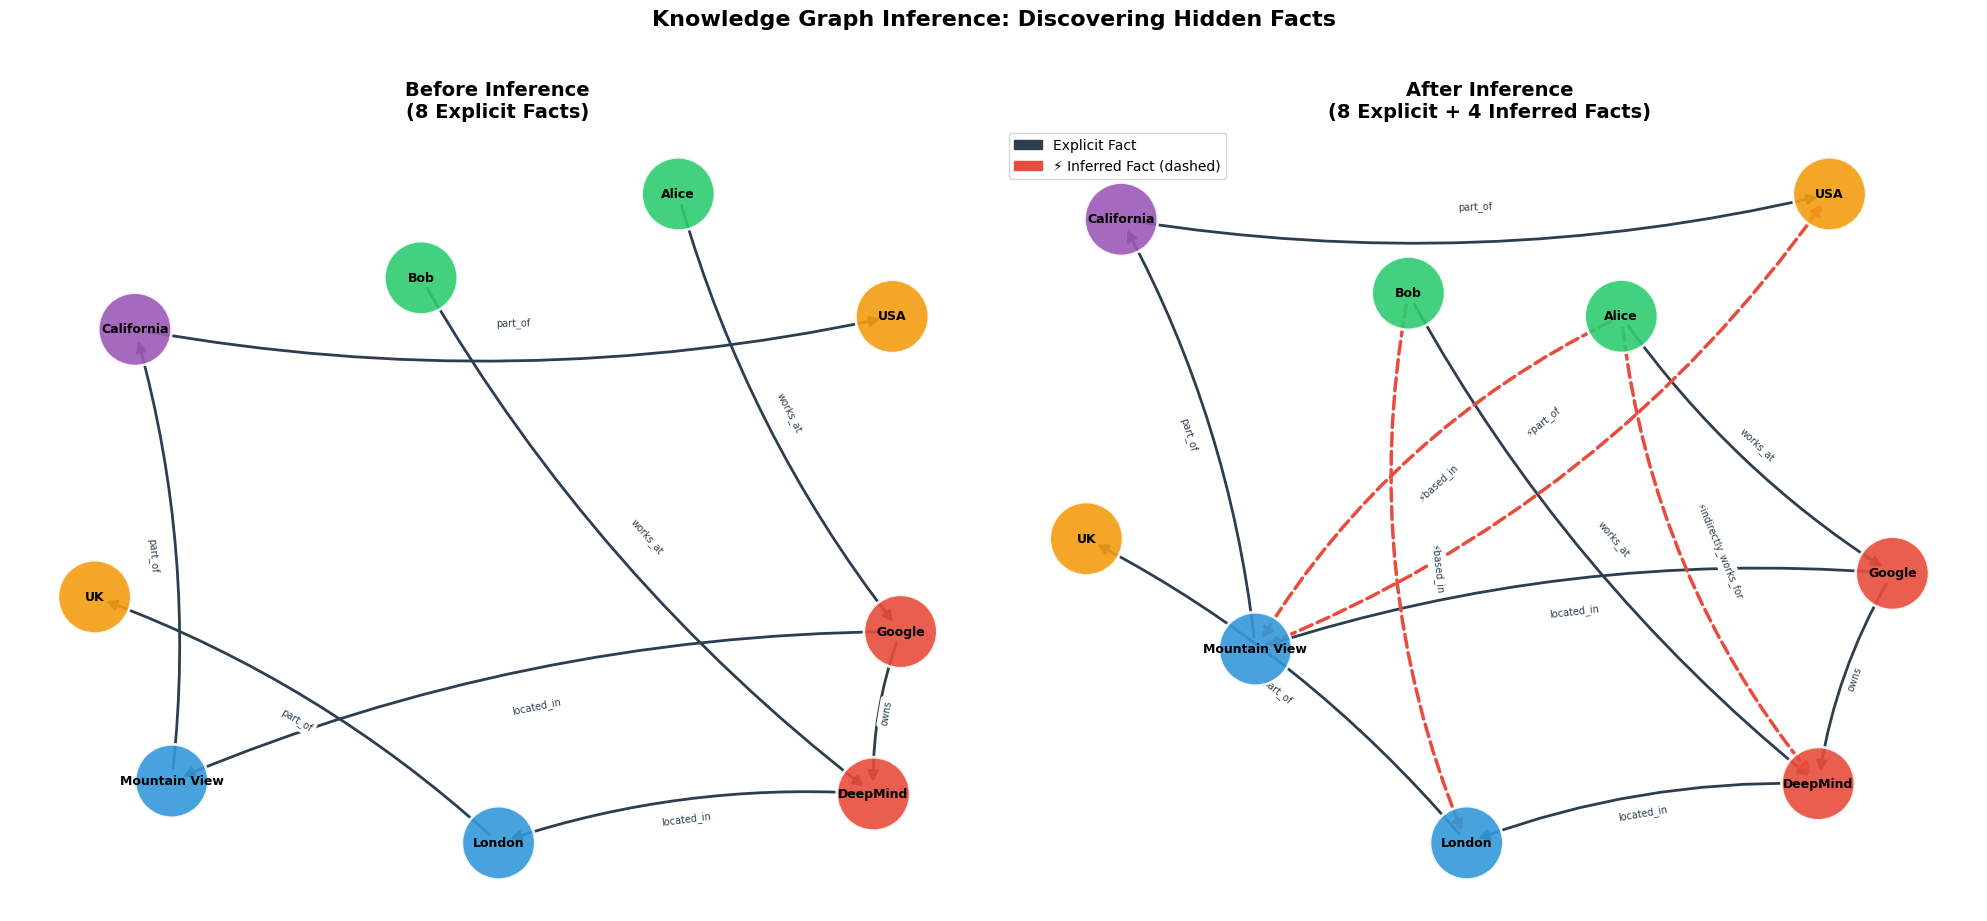

In [19]:
# --- Visualize: Explicit vs. Inferred Knowledge ---

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

def draw_kg(graph, triples, inferred, ax, title):
    pos = nx.spring_layout(graph, seed=42, k=2.0)
    colors = [graph.nodes[n].get("color", "#95a5a6") for n in graph.nodes()]
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=2800,
                            alpha=0.9, edgecolors="white", linewidths=2, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=9, font_weight="bold", ax=ax)

    explicit_edges = [(s, o) for s, _, o in triples]
    inferred_edges = [(s, o) for s, _, o in inferred]

    nx.draw_networkx_edges(graph, pos, edgelist=explicit_edges,
                            edge_color="#2c3e50", arrows=True, arrowsize=15,
                            width=2, ax=ax, connectionstyle="arc3,rad=0.1")
    if inferred_edges:
        existing = [(u, v) for u, v in inferred_edges if graph.has_edge(u, v)]
        nx.draw_networkx_edges(graph, pos, edgelist=existing,
                                edge_color="#e74c3c", arrows=True, arrowsize=15,
                                width=2.5, style="dashed", ax=ax,
                                connectionstyle="arc3,rad=0.15")

    edge_labels = {}
    for s, p, o in triples:
        edge_labels[(s, o)] = p
    for s, p, o in inferred:
        edge_labels[(s, o)] = f"⚡{p}"
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels,
                                  font_size=7, font_color="#2c3e50", ax=ax)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

# Before inference
G_before = nx.DiGraph()
for s, p, o in explicit_facts:
    if s in node_attrs:
        G_before.add_node(s, **node_attrs[s])
    if o in node_attrs:
        G_before.add_node(o, **node_attrs[o])
    G_before.add_edge(s, o, relation=p)

draw_kg(G_before, explicit_facts, [], axes[0], "Before Inference\n(8 Explicit Facts)")

draw_kg(kg.graph, explicit_facts, kg.inferred, axes[1],
        f"After Inference\n(8 Explicit + {len(kg.inferred)} Inferred Facts)")

legend_items = [
    mpatches.Patch(color="#2c3e50", label="Explicit Fact"),
    mpatches.Patch(color="#e74c3c", label="⚡ Inferred Fact (dashed)"),
]
axes[1].legend(handles=legend_items, loc="upper left", fontsize=10)

plt.suptitle("Knowledge Graph Inference: Discovering Hidden Facts",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

# Part 3: State-of-the-Art — GraphRAG & Neuro-Symbolic AI

## The Problem with Vanilla RAG

Standard RAG (Retrieval-Augmented Generation) works like this:
1. Chunk documents → embed them → store in a vector database
2. At query time, find the top-K most similar chunks
3. Feed those chunks to an LLM as context

**The fatal flaw?** Vector search finds *locally similar* chunks, but it cannot reason *globally* across an entire dataset. Ask "What are the main themes across all 10,000 documents?" and vanilla RAG falls apart.

## GraphRAG: The Current King

**GraphRAG** (pioneered by Microsoft Research, 2024) fixes this by building a Knowledge Graph from the documents first:

1. **Extract entities and relationships** from every document using an LLM
2. **Build a Knowledge Graph** connecting all extracted knowledge
3. **Detect communities** (clusters of related entities) using graph algorithms
4. **Generate community summaries** at multiple hierarchical levels
5. At query time, **traverse the graph** and use community summaries for global reasoning

### Why This Matters

| Capability | Vanilla RAG | GraphRAG |
|---|---|---|
| Find specific facts | ✅ Great | ✅ Great |
| Reason across documents | ❌ Fails | ✅ Excels |
| Explain connections | ❌ Struggles | ✅ Natural |
| Handle "what are the themes?" | ❌ Fails | ✅ Built for this |
| Traceability / Provenance | ⚠️ Limited | ✅ Full path |

## Neuro-Symbolic AI: The Hybrid Future

The frontier is **combining neural networks with symbolic reasoning:**
- **Graph Neural Networks (GNNs):** Learn node embeddings that capture both structure and features — can predict missing links
- **Vector + Graph Hybrid:** Unstructured text gets vector embeddings; structured facts get graph representations; queries use both
- **Self-Evolving Graphs:** AI agents that read documentation and automatically update the graph's schema and data in real-time

---

# Example 1: The "Digital Twin" for Drug Discovery

## The Scenario

Imagine a Knowledge Graph containing every known chemical compound, protein, gene, and clinical trial result. An AI agent traverses this graph to find **hidden paths** — connections that no human researcher mapped, but that the graph's structure reveals.

## The Mind-Blower

> Drug A inhibits Protein B. Protein B is linked to Disease C in a specific genetic population.
> The AI **reasons** that Drug A could be repurposed for Disease C — potentially saving **10 years of R&D** and hundreds of millions of dollars.

This isn't science fiction — it's exactly how Knowledge Graphs are being used at companies like **BenevolentAI**, **Insilico Medicine**, and within **NIH's NCATS** program.

In [20]:
# --- Example 1: Biomedical Knowledge Graph for Drug Repurposing ---

bio_kg = nx.DiGraph()

bio_entities = {
    # Drugs
    "Baricitinib":     {"type": "Drug",     "color": "#e74c3c", "shape": "s"},
    "Remdesivir":      {"type": "Drug",     "color": "#e74c3c", "shape": "s"},
    "Metformin":       {"type": "Drug",     "color": "#e74c3c", "shape": "s"},
    # Proteins
    "JAK1/JAK2":       {"type": "Protein",  "color": "#3498db", "shape": "o"},
    "AAK1":            {"type": "Protein",  "color": "#3498db", "shape": "o"},
    "AMPK":            {"type": "Protein",  "color": "#3498db", "shape": "o"},
    "ACE2":            {"type": "Protein",  "color": "#3498db", "shape": "o"},
    "mTOR":            {"type": "Protein",  "color": "#3498db", "shape": "o"},
    # Genes
    "BRCA1":           {"type": "Gene",     "color": "#2ecc71", "shape": "^"},
    "TP53":            {"type": "Gene",     "color": "#2ecc71", "shape": "^"},
    # Diseases
    "Rheumatoid\nArthritis": {"type": "Disease", "color": "#9b59b6", "shape": "D"},
    "COVID-19":        {"type": "Disease",  "color": "#9b59b6", "shape": "D"},
    "Type 2\nDiabetes":{"type": "Disease",  "color": "#9b59b6", "shape": "D"},
    "Breast\nCancer":  {"type": "Disease",  "color": "#9b59b6", "shape": "D"},
    "Aging":           {"type": "Disease",  "color": "#9b59b6", "shape": "D"},
    # Pathways
    "Cytokine Storm":  {"type": "Pathway",  "color": "#f39c12", "shape": "p"},
    "Viral Entry":     {"type": "Pathway",  "color": "#f39c12", "shape": "p"},
    "Cell Growth":     {"type": "Pathway",  "color": "#f39c12", "shape": "p"},
}

for entity, attrs in bio_entities.items():
    bio_kg.add_node(entity, **attrs)

bio_relations = [
    # Baricitinib path → COVID-19 (the real BenevolentAI discovery!)
    ("Baricitinib",  "JAK1/JAK2",    "inhibits"),
    ("Baricitinib",  "AAK1",         "inhibits"),
    ("JAK1/JAK2",    "Cytokine Storm","regulates"),
    ("Cytokine Storm","COVID-19",    "drives"),
    ("AAK1",         "Viral Entry",  "facilitates"),
    ("Viral Entry",  "COVID-19",     "causes"),
    ("Remdesivir",   "COVID-19",     "treats"),
    ("ACE2",         "Viral Entry",  "receptor_for"),

    # Baricitinib's original use
    ("Baricitinib",  "Rheumatoid\nArthritis", "approved_for"),

    # Metformin → multiple disease paths
    ("Metformin",    "AMPK",         "activates"),
    ("AMPK",         "mTOR",         "inhibits"),
    ("mTOR",         "Cell Growth",  "promotes"),
    ("Cell Growth",  "Breast\nCancer","drives"),
    ("Metformin",    "Type 2\nDiabetes", "approved_for"),
    ("AMPK",         "Aging",        "slows"),

    # Gene-disease links
    ("BRCA1",        "Breast\nCancer","risk_factor_for"),
    ("TP53",         "Cell Growth",  "suppresses"),
]

for s, o, p in bio_relations:
    bio_kg.add_edge(s, o, relation=p)

print(f"🧬 Biomedical Knowledge Graph: {bio_kg.number_of_nodes()} entities, {bio_kg.number_of_edges()} relationships")
print(f"   Entity types: Drug, Protein, Gene, Disease, Pathway")

🧬 Biomedical Knowledge Graph: 18 entities, 17 relationships
   Entity types: Drug, Protein, Gene, Disease, Pathway


In [21]:
# --- Drug Repurposing: Finding Hidden Paths ---

def find_drug_disease_paths(graph, drug: str, disease: str, max_depth: int = 5):
    """Find all paths from a drug to a disease in the KG."""
    try:
        paths = list(nx.all_simple_paths(graph, drug, disease, cutoff=max_depth))
        return paths
    except nx.NetworkXError:
        return []

def explain_path(graph, path):
    """Generate a human-readable explanation of a reasoning path."""
    steps = []
    for i in range(len(path) - 1):
        rel = graph[path[i]][path[i+1]].get("relation", "related_to")
        steps.append(f"  {path[i]}  —[{rel}]→  {path[i+1]}")
    return "\n".join(steps)


print("=" * 70)
print("🔬 AI DRUG REPURPOSING ENGINE")
print("   Finding hidden therapeutic connections via graph traversal")
print("=" * 70)

# The real BenevolentAI discovery: Baricitinib → COVID-19
print("\n\n🎯 Query: Can 'Baricitinib' (an arthritis drug) treat 'COVID-19'?\n")

paths = find_drug_disease_paths(bio_kg, "Baricitinib", "COVID-19")
print(f"   Found {len(paths)} reasoning path(s)!\n")

for i, path in enumerate(paths, 1):
    print(f"   --- Path {i} (length: {len(path)-1} hops) ---")
    print(explain_path(bio_kg, path))
    print()

print("   🧠 INSIGHT: Baricitinib inhibits both JAK1/JAK2 (calming cytokine storms)")
print("   AND AAK1 (blocking viral entry). This dual mechanism was discovered by")
print("   BenevolentAI in Feb 2020 — purely through KG reasoning.")
print("   It became an FDA-approved COVID-19 treatment in 2022.")

# Metformin → Cancer
print("\n\n" + "=" * 70)
print("🎯 Query: Can 'Metformin' (a diabetes drug) affect 'Breast Cancer'?\n")

paths2 = find_drug_disease_paths(bio_kg, "Metformin", "Breast\nCancer")
print(f"   Found {len(paths2)} reasoning path(s)!\n")

for i, path in enumerate(paths2, 1):
    print(f"   --- Path {i} (length: {len(path)-1} hops) ---")
    print(explain_path(bio_kg, path))
    print()

print("   🧠 INSIGHT: Metformin activates AMPK, which inhibits mTOR, which")
print("   promotes cell growth — a driver of breast cancer. Clinical trials")
print("   are now investigating Metformin for cancer prevention.")

🔬 AI DRUG REPURPOSING ENGINE
   Finding hidden therapeutic connections via graph traversal


🎯 Query: Can 'Baricitinib' (an arthritis drug) treat 'COVID-19'?

   Found 2 reasoning path(s)!

   --- Path 1 (length: 3 hops) ---
  Baricitinib  —[inhibits]→  JAK1/JAK2
  JAK1/JAK2  —[regulates]→  Cytokine Storm
  Cytokine Storm  —[drives]→  COVID-19

   --- Path 2 (length: 3 hops) ---
  Baricitinib  —[inhibits]→  AAK1
  AAK1  —[facilitates]→  Viral Entry
  Viral Entry  —[causes]→  COVID-19

   🧠 INSIGHT: Baricitinib inhibits both JAK1/JAK2 (calming cytokine storms)
   AND AAK1 (blocking viral entry). This dual mechanism was discovered by
   BenevolentAI in Feb 2020 — purely through KG reasoning.
   It became an FDA-approved COVID-19 treatment in 2022.


🎯 Query: Can 'Metformin' (a diabetes drug) affect 'Breast Cancer'?

   Found 1 reasoning path(s)!

   --- Path 1 (length: 4 hops) ---
  Metformin  —[activates]→  AMPK
  AMPK  —[inhibits]→  mTOR
  mTOR  —[promotes]→  Cell Growth
  Cell Growth 

In [23]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 8.9 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


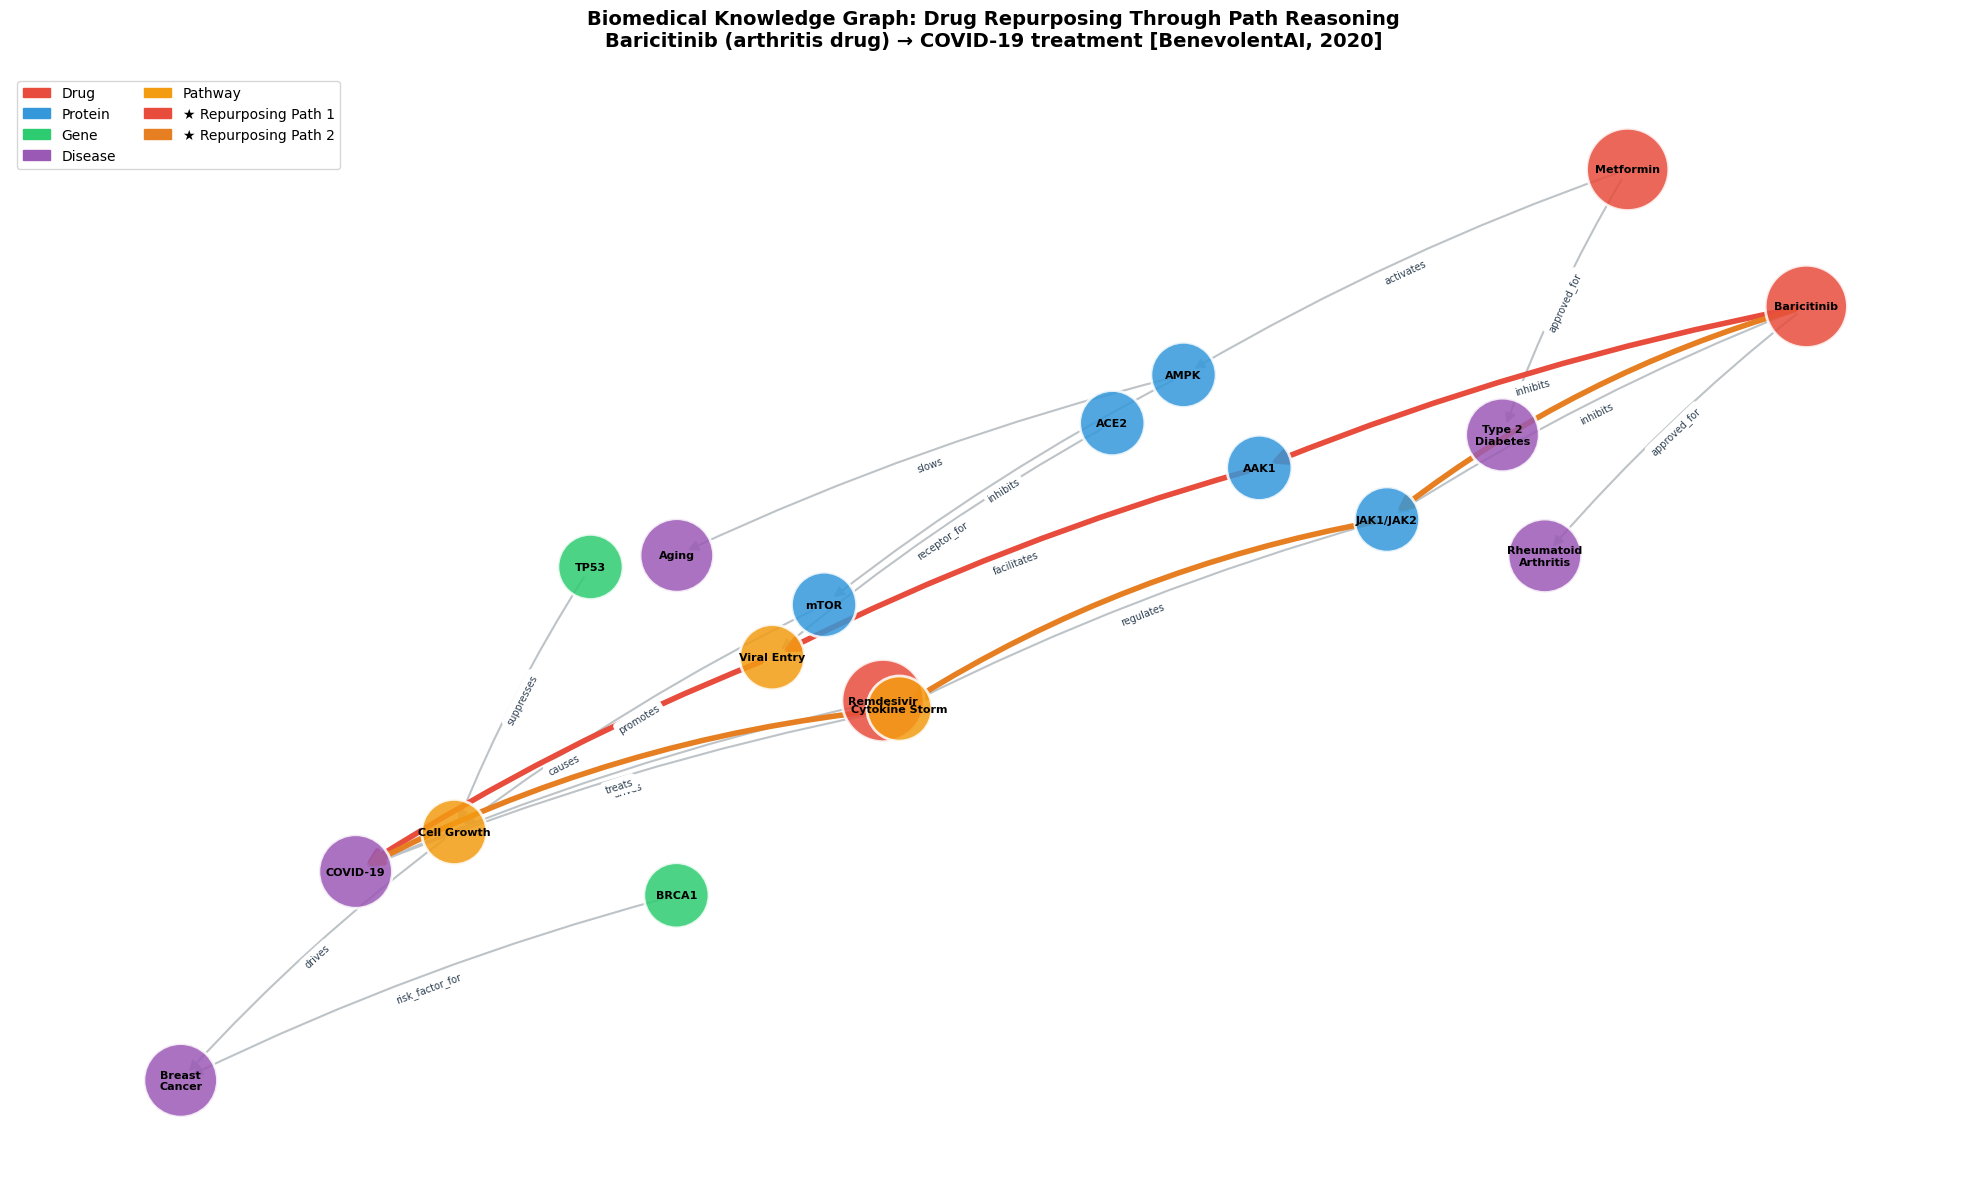

In [24]:
# --- Visualize the Biomedical KG with highlighted repurposing paths ---

fig, ax = plt.subplots(1, 1, figsize=(20, 12))

pos = nx.kamada_kawai_layout(bio_kg)

type_colors = {"Drug": "#e74c3c", "Protein": "#3498db", "Gene": "#2ecc71",
               "Disease": "#9b59b6", "Pathway": "#f39c12"}
node_colors = [bio_entities[n]["color"] for n in bio_kg.nodes()]
node_sizes = [3500 if bio_entities[n]["type"] == "Drug" else
              2800 if bio_entities[n]["type"] == "Disease" else 2200
              for n in bio_kg.nodes()]

nx.draw_networkx_nodes(bio_kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(bio_kg, pos, font_size=8, font_weight="bold", ax=ax)

# Draw regular edges
regular_edges = [(u, v) for u, v in bio_kg.edges()]
nx.draw_networkx_edges(bio_kg, pos, edgelist=regular_edges, edge_color="#bdc3c7",
                        arrows=True, arrowsize=15, width=1.5, ax=ax,
                        connectionstyle="arc3,rad=0.05")

# Highlight Baricitinib → COVID-19 paths
highlight_path = ["Baricitinib", "AAK1", "Viral Entry", "COVID-19"]
highlight_edges = [(highlight_path[i], highlight_path[i+1]) for i in range(len(highlight_path)-1)]
nx.draw_networkx_edges(bio_kg, pos, edgelist=highlight_edges, edge_color="#e74c3c",
                        arrows=True, arrowsize=20, width=4, ax=ax,
                        connectionstyle="arc3,rad=0.05")

highlight_path2 = ["Baricitinib", "JAK1/JAK2", "Cytokine Storm", "COVID-19"]
highlight_edges2 = [(highlight_path2[i], highlight_path2[i+1]) for i in range(len(highlight_path2)-1)]
nx.draw_networkx_edges(bio_kg, pos, edgelist=highlight_edges2, edge_color="#e67e22",
                        arrows=True, arrowsize=20, width=4, ax=ax,
                        connectionstyle="arc3,rad=0.1")

edge_labels = {(s, o): p for s, o, p in bio_relations}
nx.draw_networkx_edge_labels(bio_kg, pos, edge_labels=edge_labels,
                              font_size=7, font_color="#2c3e50", ax=ax)

legend_items = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
legend_items.append(mpatches.Patch(color="#e74c3c", label="★ Repurposing Path 1"))
legend_items.append(mpatches.Patch(color="#e67e22", label="★ Repurposing Path 2"))
ax.legend(handles=legend_items, loc="upper left", fontsize=10, ncol=2)

ax.set_title("Biomedical Knowledge Graph: Drug Repurposing Through Path Reasoning\n"
             "Baricitinib (arthritis drug) → COVID-19 treatment [BenevolentAI, 2020]",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

---

# Example 2: Fraud Detection in Shadow Banking

## The Scenario

Traditional fraud systems look at **individual transactions** — "Is this $5,000 transfer suspicious?" That's like looking at one tree and missing the forest.

A Knowledge Graph looks at the **topology of the entire network** — the shape of relationships between people, companies, and transactions.

## The Mind-Blower

> Money flows from Person A → Shell Company B → Offshore Corp C → Back to Person A through **50 intermediaries**. No single transaction is flagged, but the KG identifies the **circular structure** — a money laundering ring that no human analyst or SQL query could feasibly map.

This is how **HSBC**, **JPMorgan**, and **FinCEN** use graph analytics for anti-money-laundering (AML).

In [34]:
# --- Example 2: Fraud Detection — Circular Money Laundering ---

import random
random.seed(42)

fraud_kg = nx.MultiDiGraph()

people = ["Viktor Petrov", "Elena Sokolova", "Marcus Chen", "Raj Malhotra"]
shells = [f"Shell Corp {chr(65+i)}" for i in range(11)]  # A through K
offshores = ["Cayman Holdings Ltd", "Panama Trust SA", "Cyprus Capital LLC", "BVI Global Trust"]
banks = ["Swiss National Bank", "Bank of Singapore", "Deutsche Bank", "HSBC Hong Kong"]

for p in people:
    fraud_kg.add_node(p, type="Person", color="#e74c3c")
for s in shells:
    fraud_kg.add_node(s, type="Shell Company", color="#f39c12")
for o in offshores:
    fraud_kg.add_node(o, type="Offshore Entity", color="#9b59b6")
for b in banks:
    fraud_kg.add_node(b, type="Bank", color="#3498db")

fraud_transactions = [
    # The laundering ring: circular flow
    ("Viktor Petrov",     "Shell Corp A",      "transfers_to",  "$2.1M", "2025-01-15"),
    ("Shell Corp A",      "Shell Corp B",      "transfers_to",  "$2.0M", "2025-01-17"),
    ("Shell Corp B",      "Cayman Holdings Ltd","transfers_to", "$1.9M", "2025-01-20"),
    ("Cayman Holdings Ltd","Shell Corp C",     "transfers_to",  "$1.85M","2025-01-25"),
    ("Shell Corp C",      "Shell Corp D",      "transfers_to",  "$1.8M", "2025-02-01"),
    ("Shell Corp D",      "Swiss National Bank","transfers_to", "$1.75M","2025-02-05"),
    ("Swiss National Bank","Shell Corp E",     "transfers_to",  "$1.7M", "2025-02-10"),
    ("Shell Corp E",      "Viktor Petrov",     "transfers_to",  "$1.65M","2025-02-15"),  # CIRCLE CLOSES

    # Second ring
    ("Elena Sokolova",    "Shell Corp F",      "transfers_to",  "$800K", "2025-03-01"),
    ("Shell Corp F",      "Panama Trust SA",   "transfers_to",  "$780K", "2025-03-05"),
    ("Panama Trust SA",   "Shell Corp G",      "transfers_to",  "$760K", "2025-03-10"),
    ("Shell Corp G",      "Elena Sokolova",    "transfers_to",  "$740K", "2025-03-15"),  # CIRCLE CLOSES

    # Third ring: trade-based laundering via inflated invoices
    ("Raj Malhotra",      "Shell Corp I",      "transfers_to",  "$3.5M", "2025-05-01"),
    ("Shell Corp I",      "HSBC Hong Kong",    "transfers_to",  "$3.4M", "2025-05-04"),
    ("HSBC Hong Kong",    "BVI Global Trust",  "transfers_to",  "$3.3M", "2025-05-08"),
    ("BVI Global Trust",  "Shell Corp J",      "transfers_to",  "$3.2M", "2025-05-12"),
    ("Shell Corp J",      "Shell Corp K",      "transfers_to",  "$3.1M", "2025-05-17"),
    ("Shell Corp K",      "Bank of Singapore", "transfers_to",  "$3.0M", "2025-05-22"),
    ("Bank of Singapore", "Raj Malhotra",      "transfers_to",  "$2.9M", "2025-05-28"),  # CIRCLE CLOSES

    # Legitimate transactions (noise)
    ("Marcus Chen",       "Deutsche Bank",     "transfers_to",  "$50K",  "2025-04-01"),
    ("Marcus Chen",       "Shell Corp H",      "invests_in",    "$120K", "2025-04-05"),
    ("Shell Corp H",      "Cyprus Capital LLC", "transfers_to", "$100K", "2025-04-10"),

    # Ownership relationships
    ("Viktor Petrov",     "Shell Corp A",      "beneficial_owner", "", ""),
    ("Viktor Petrov",     "Shell Corp D",      "beneficial_owner", "", ""),
    ("Elena Sokolova",    "Shell Corp F",      "beneficial_owner", "", ""),
    ("Elena Sokolova",    "Shell Corp G",      "beneficial_owner", "", ""),
    ("Raj Malhotra",      "Shell Corp I",      "beneficial_owner", "", ""),
    ("Raj Malhotra",      "Shell Corp K",      "beneficial_owner", "", ""),
]

for s, o, rel, amount, date in fraud_transactions:
    fraud_kg.add_edge(s, o, relation=rel, amount=amount, date=date)

print(f"🏦 Financial Network: {fraud_kg.number_of_nodes()} entities, {fraud_kg.number_of_edges()} relationships")
print(f"   People: {len(people)}, Shell Companies: {len(shells)}, Offshore: {len(offshores)}, Banks: {len(banks)}")

🏦 Financial Network: 23 entities, 28 relationships
   People: 4, Shell Companies: 11, Offshore: 4, Banks: 4


In [35]:
# --- Fraud Detection: Cycle Detection Algorithm ---

def detect_circular_transfers(graph) -> List[List[str]]:
    """Detect circular money flows in a financial knowledge graph.
    Only considers 'transfers_to' edges to find laundering rings."""

    transfer_graph = nx.DiGraph()
    for u, v, data in graph.edges(data=True):
        if data.get("relation") == "transfers_to":
            transfer_graph.add_edge(u, v, **data)

    cycles = list(nx.simple_cycles(transfer_graph))
    return [c for c in cycles if len(c) >= 3]  # Only meaningful cycles


def analyze_ring(graph, cycle):
    """Analyze a detected laundering ring."""
    total_in = 0
    total_out = 0
    transactions = []

    for i in range(len(cycle)):
        src = cycle[i]
        dst = cycle[(i + 1) % len(cycle)]
        edges = graph[src][dst]
        edge_data = None
        for key in edges:
            if edges[key].get("relation") == "transfers_to":
                edge_data = edges[key]
                break
        if edge_data is None:
            edge_data = edges[list(edges.keys())[0]]
        amount_str = edge_data.get("amount", "$0")
        amount = float(amount_str.replace("$", "").replace("M", "000000").replace("K", "000")) if amount_str else 0

        if i == 0:
            total_in = amount
        if i == len(cycle) - 1:
            total_out = amount

        transactions.append({
            "from": src, "to": dst,
            "amount": amount_str, "date": edge_data.get("date", ""),
            "relation": edge_data.get("relation", "")
        })

    laundering_fee = total_in - total_out if total_in > total_out else 0

    return {
        "cycle_length": len(cycle),
        "entities_involved": cycle,
        "transactions": transactions,
        "estimated_laundered": total_in,
        "laundering_fee_pct": (laundering_fee / total_in * 100) if total_in > 0 else 0
    }


print("=" * 70)
print("🚨 FRAUD DETECTION ENGINE: Circular Transfer Analysis")
print("=" * 70)

cycles = detect_circular_transfers(fraud_kg)
print(f"\n⚠️  Detected {len(cycles)} suspicious circular transfer pattern(s)!\n")

for i, cycle in enumerate(cycles, 1):
    analysis = analyze_ring(fraud_kg, cycle)
    print(f"{'─' * 60}")
    print(f"🔴 ALERT #{i}: Circular Money Flow Detected")
    print(f"{'─' * 60}")
    print(f"   Ring size:    {analysis['cycle_length']} entities")
    print(f"   Entities:     {' → '.join(cycle)} → {cycle[0]}")
    print(f"\n   Transaction chain:")
    for tx in analysis["transactions"]:
        print(f"     {tx['date']}  {tx['from']:25s} → {tx['to']:25s}  {tx['amount']}")
    if analysis["laundering_fee_pct"] > 0:
        print(f"\n   💰 Estimated amount laundered: ${analysis['estimated_laundered']:,.0f}")
        print(f"   📉 Money lost in transit (fees): {analysis['laundering_fee_pct']:.1f}%")
    print()

print("\n💡 KEY INSIGHT: No single transaction is suspicious on its own.")
print("   It's the TOPOLOGY — the circular structure — that reveals the fraud.")
print("   This is why graph databases beat SQL for financial crime detection.")

🚨 FRAUD DETECTION ENGINE: Circular Transfer Analysis

⚠️  Detected 3 suspicious circular transfer pattern(s)!

────────────────────────────────────────────────────────────
🔴 ALERT #1: Circular Money Flow Detected
────────────────────────────────────────────────────────────
   Ring size:    7 entities
   Entities:     BVI Global Trust → Shell Corp J → Shell Corp K → Bank of Singapore → Raj Malhotra → Shell Corp I → HSBC Hong Kong → BVI Global Trust

   Transaction chain:
     2025-05-12  BVI Global Trust          → Shell Corp J               $3.2M
     2025-05-17  Shell Corp J              → Shell Corp K               $3.1M
     2025-05-22  Shell Corp K              → Bank of Singapore          $3.0M
     2025-05-28  Bank of Singapore         → Raj Malhotra               $2.9M
     2025-05-01  Raj Malhotra              → Shell Corp I               $3.5M
     2025-05-04  Shell Corp I              → HSBC Hong Kong             $3.4M
     2025-05-08  HSBC Hong Kong            → BVI Global T

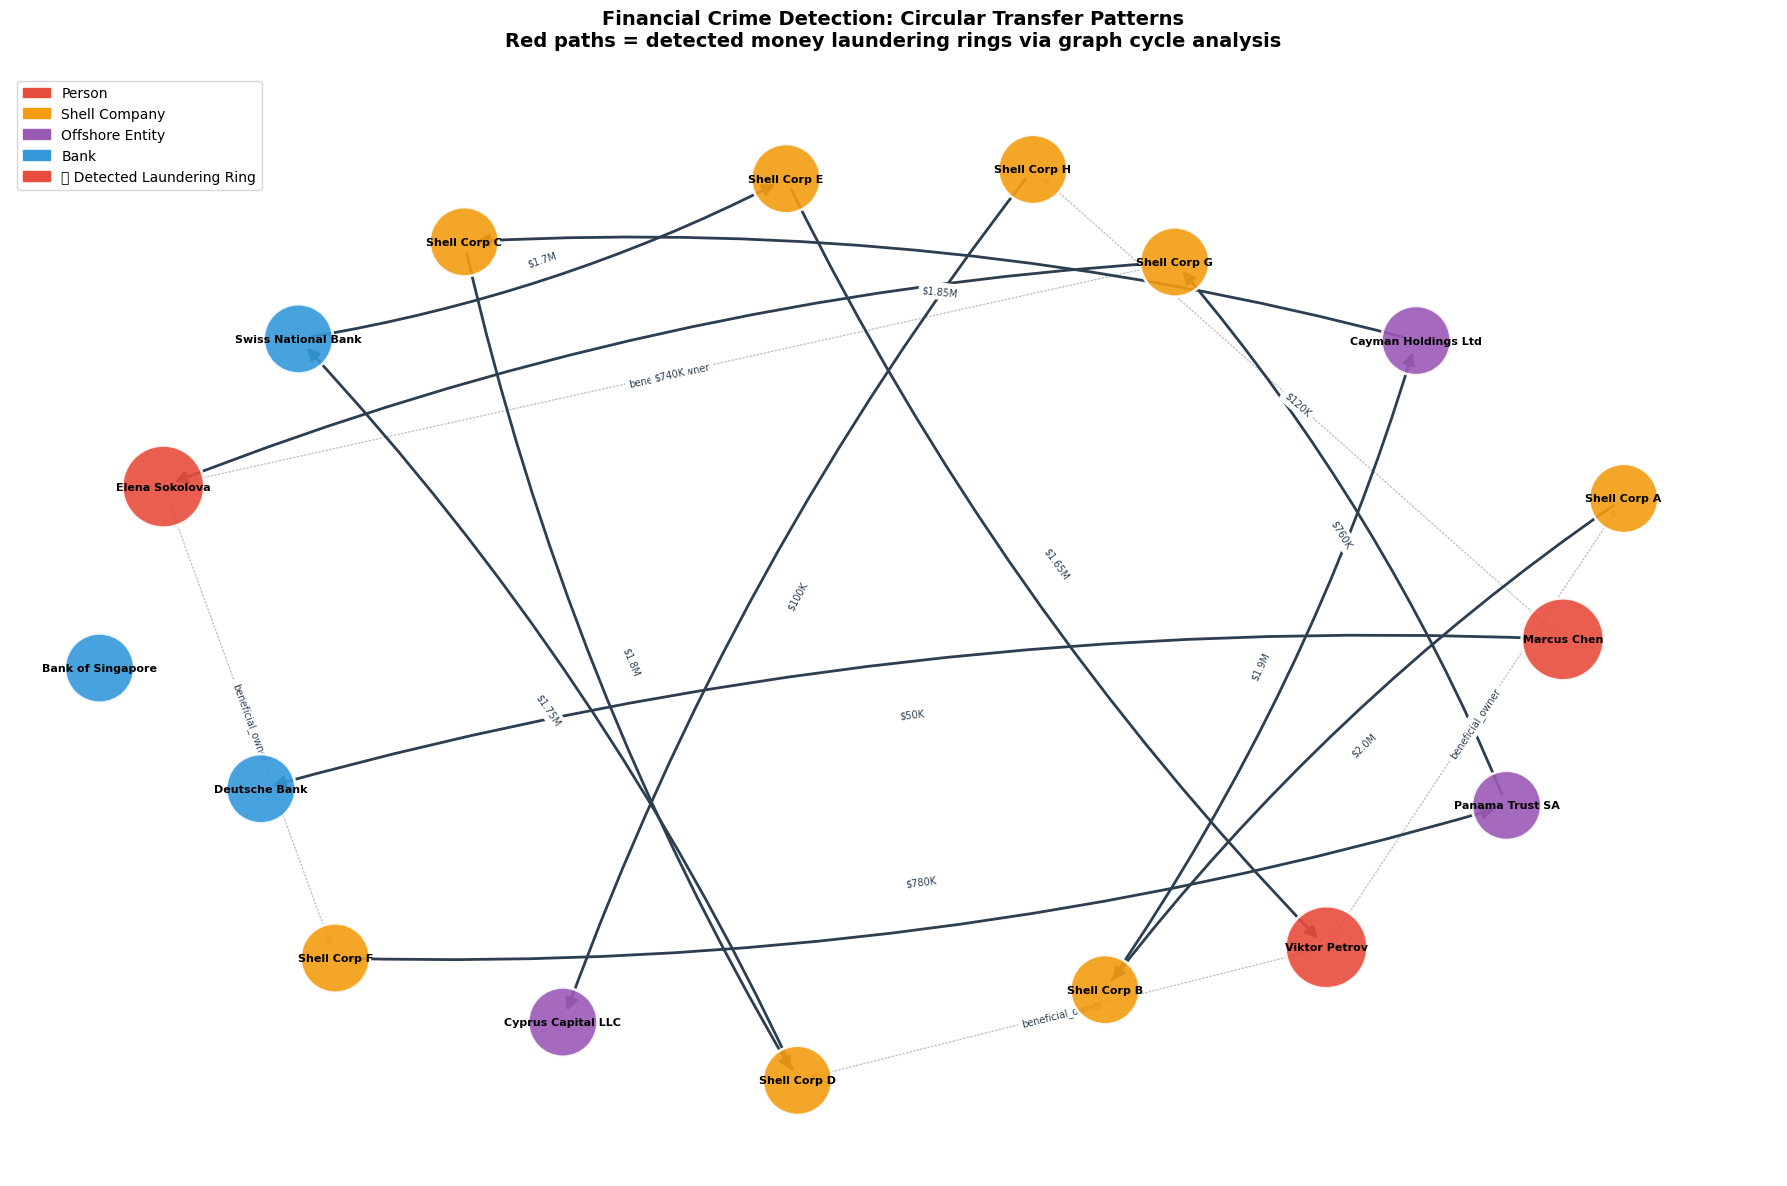

In [27]:
# --- Visualize the Fraud Network ---

fig, ax = plt.subplots(1, 1, figsize=(18, 12))

pos = nx.spring_layout(fraud_kg, seed=123, k=2.2)

type_color_map = {"Person": "#e74c3c", "Shell Company": "#f39c12",
                  "Offshore Entity": "#9b59b6", "Bank": "#3498db"}
node_colors = [fraud_kg.nodes[n].get("color", "#95a5a6") for n in fraud_kg.nodes()]
node_sizes = [3500 if fraud_kg.nodes[n].get("type") == "Person" else 2500
              for n in fraud_kg.nodes()]

nx.draw_networkx_nodes(fraud_kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.9, edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(fraud_kg, pos, font_size=8, font_weight="bold", ax=ax)

# Separate transfer edges from ownership edges
transfer_edges = [(u, v) for u, v, d in fraud_kg.edges(data=True) if d.get("relation") == "transfers_to"]
other_edges = [(u, v) for u, v, d in fraud_kg.edges(data=True) if d.get("relation") != "transfers_to"]

nx.draw_networkx_edges(fraud_kg, pos, edgelist=other_edges, edge_color="#bdc3c7",
                        arrows=True, arrowsize=12, width=1, style="dotted", ax=ax)
nx.draw_networkx_edges(fraud_kg, pos, edgelist=transfer_edges, edge_color="#2c3e50",
                        arrows=True, arrowsize=18, width=2, ax=ax,
                        connectionstyle="arc3,rad=0.08")

# Highlight the detected cycles in red
if cycles:
    for cycle in cycles:
        cycle_edges = []
        for j in range(len(cycle)):
            src = cycle[j]
            dst = cycle[(j + 1) % len(cycle)]
            if fraud_kg.has_edge(src, dst):
                cycle_edges.append((src, dst))
        nx.draw_networkx_edges(fraud_kg, pos, edgelist=cycle_edges, edge_color="#e74c3c",
                                arrows=True, arrowsize=22, width=4, ax=ax,
                                connectionstyle="arc3,rad=0.08")

edge_labels = {}
for u, v, d in fraud_kg.edges(data=True):
    amount = d.get("amount", "")
    rel = d.get("relation", "")
    label = amount if amount else rel
    edge_labels[(u, v)] = label

nx.draw_networkx_edge_labels(fraud_kg, pos, edge_labels=edge_labels,
                              font_size=7, font_color="#2c3e50", ax=ax)

legend_items = [mpatches.Patch(color=c, label=t) for t, c in type_color_map.items()]
legend_items.append(mpatches.Patch(color="#e74c3c", label="🚨 Detected Laundering Ring"))
ax.legend(handles=legend_items, loc="upper left", fontsize=10)

ax.set_title("Financial Crime Detection: Circular Transfer Patterns\n"
             "Red paths = detected money laundering rings via graph cycle analysis",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

---

# Example 3: The "Virtual Software Engineer" — KG as an Agent's Operating System

## The Scenario

Your AI agent doesn't just search your emails. It **maps your world.** It knows that:
- "Project Phoenix" mentioned in **Slack** is the same as the **GitHub Repo** your lead developer just pushed to
- Which is linked to the **Jira Ticket** due tomorrow
- Which references a **Confluence page** with the architecture design
- Which was discussed in yesterday's **Zoom meeting**

The Knowledge Graph provides the **unified context** the agent needs to actually do the work — not just answer questions, but take action across systems.

## Why This Matters for AI Agents

Without a KG, an AI agent sees **disconnected data silos**. With a KG, it sees **a coherent world model** — the operating system for intelligent action.

In [28]:
# --- Example 3: AI Agent's World Model — Unified Context Graph ---

agent_kg = nx.DiGraph()

# Entities across multiple systems
agent_entities = {
    # Projects
    "Project Phoenix":      {"type": "Project",     "color": "#e74c3c", "source": "cross-system"},
    # People
    "Sarah (Tech Lead)":    {"type": "Person",      "color": "#2ecc71", "source": "HR System"},
    "Alex (Backend Dev)":   {"type": "Person",      "color": "#2ecc71", "source": "HR System"},
    "Jordan (PM)":          {"type": "Person",      "color": "#2ecc71", "source": "HR System"},
    # GitHub
    "phoenix-api (repo)":   {"type": "GitHub Repo", "color": "#333333", "source": "GitHub"},
    "PR #247: Auth Refactor":{"type": "Pull Request","color": "#333333", "source": "GitHub"},
    "PR #251: API v2":      {"type": "Pull Request","color": "#333333", "source": "GitHub"},
    # Jira
    "PHIX-1042: Auth\nMigration": {"type": "Jira Ticket", "color": "#0052cc", "source": "Jira"},
    "PHIX-1038: API\nRedesign":   {"type": "Jira Ticket", "color": "#0052cc", "source": "Jira"},
    "Sprint 23":            {"type": "Sprint",      "color": "#0052cc", "source": "Jira"},
    # Confluence
    "Auth Architecture\nDoc":{"type": "Document",   "color": "#172b4d", "source": "Confluence"},
    "API v2 Design\nSpec":  {"type": "Document",    "color": "#172b4d", "source": "Confluence"},
    # Slack
    "#phoenix-dev":         {"type": "Slack Channel","color": "#4a154b", "source": "Slack"},
    "Slack Thread:\nAuth Debate": {"type": "Thread", "color": "#4a154b", "source": "Slack"},
    # Calendar
    "Sprint Review\n(Tomorrow 2pm)": {"type": "Meeting", "color": "#f39c12", "source": "Calendar"},
    "1:1 Sarah/Jordan\n(Today 4pm)": {"type": "Meeting", "color": "#f39c12", "source": "Calendar"},
    # Deadlines
    "March 15 Deadline":    {"type": "Deadline",    "color": "#e74c3c", "source": "Jira"},
}

for entity, attrs in agent_entities.items():
    agent_kg.add_node(entity, **attrs)

agent_relations = [
    # Project connections
    ("Project Phoenix",     "phoenix-api (repo)",       "has_repo"),
    ("Project Phoenix",     "#phoenix-dev",             "has_channel"),
    ("Project Phoenix",     "Sprint 23",                "current_sprint"),
    ("Project Phoenix",     "March 15 Deadline",        "deadline"),

    # People → Work
    ("Sarah (Tech Lead)",   "PR #247: Auth Refactor",   "authored"),
    ("Sarah (Tech Lead)",   "Auth Architecture\nDoc",   "wrote"),
    ("Sarah (Tech Lead)",   "Slack Thread:\nAuth Debate","started"),
    ("Alex (Backend Dev)",  "PR #251: API v2",          "authored"),
    ("Alex (Backend Dev)",  "API v2 Design\nSpec",      "wrote"),
    ("Jordan (PM)",         "Sprint 23",                "manages"),
    ("Jordan (PM)",         "PHIX-1042: Auth\nMigration","created"),

    # Code → Tickets
    ("PR #247: Auth Refactor", "PHIX-1042: Auth\nMigration", "resolves"),
    ("PR #251: API v2",     "PHIX-1038: API\nRedesign",     "resolves"),

    # Tickets → Sprint
    ("PHIX-1042: Auth\nMigration", "Sprint 23",        "in_sprint"),
    ("PHIX-1038: API\nRedesign",   "Sprint 23",        "in_sprint"),

    # Documents → Discussions
    ("Auth Architecture\nDoc", "Slack Thread:\nAuth Debate", "discussed_in"),
    ("Slack Thread:\nAuth Debate", "#phoenix-dev",     "posted_in"),

    # Meetings
    ("Sprint Review\n(Tomorrow 2pm)", "Sprint 23",     "reviews"),
    ("Sprint Review\n(Tomorrow 2pm)", "Project Phoenix","about"),
    ("1:1 Sarah/Jordan\n(Today 4pm)", "Sarah (Tech Lead)", "attendee"),
    ("1:1 Sarah/Jordan\n(Today 4pm)", "Jordan (PM)",       "attendee"),
    ("1:1 Sarah/Jordan\n(Today 4pm)", "PHIX-1042: Auth\nMigration", "agenda_item"),

    # Repo → PRs
    ("phoenix-api (repo)",  "PR #247: Auth Refactor",   "contains"),
    ("phoenix-api (repo)",  "PR #251: API v2",          "contains"),
]

for s, o, p in agent_relations:
    agent_kg.add_edge(s, o, relation=p)

print(f"🤖 AI Agent's World Model: {agent_kg.number_of_nodes()} entities, {agent_kg.number_of_edges()} relationships")
print(f"   Data sources unified: GitHub, Jira, Confluence, Slack, Calendar, HR")

🤖 AI Agent's World Model: 17 entities, 24 relationships
   Data sources unified: GitHub, Jira, Confluence, Slack, Calendar, HR


In [29]:
# --- AI Agent Context Resolution: The Power of Unified Knowledge ---

def agent_context_query(graph, query: str):
    """Simulate an AI agent resolving context across data silos."""
    print(f"🤖 Agent Query: \"{query}\"\n")
    print("   Traversing Knowledge Graph for unified context...\n")

agent_context_query(agent_kg, "What do I need to prepare for tomorrow's sprint review?")

# The agent traverses: Sprint Review → Sprint 23 → all tickets → all PRs → all people
review_node = "Sprint Review\n(Tomorrow 2pm)"

print("   📅 Meeting: Sprint Review (Tomorrow 2pm)")
print("   ├── About: Project Phoenix")
print("   ├── Reviews: Sprint 23")
print("   │")

# Find tickets in the sprint
sprint_tickets = [v for u, v, d in agent_kg.edges(data=True)
                  if d.get("relation") == "in_sprint" and v == "Sprint 23"]
# Actually get tickets pointing to Sprint 23
sprint_tickets = [u for u, v, d in agent_kg.edges(data=True)
                  if d.get("relation") == "in_sprint" and v == "Sprint 23"]

print("   ├── 📋 Tickets in Sprint:")
for ticket in sprint_tickets:
    # Find PR that resolves this ticket
    resolving_prs = [u for u, v, d in agent_kg.edges(data=True)
                     if d.get("relation") == "resolves" and v == ticket]
    # Find who authored the PR
    for pr in resolving_prs:
        authors = [u for u, v, d in agent_kg.edges(data=True)
                   if d.get("relation") == "authored" and v == pr]
        author = authors[0] if authors else "Unknown"
        clean_ticket = ticket.replace("\n", " ")
        print(f"   │   ├── {clean_ticket}")
        print(f"   │   │   ├── PR: {pr}")
        print(f"   │   │   └── Author: {author}")

# Find related docs
print("   │")
print("   ├── 📄 Related Documentation:")
docs = [n for n in agent_kg.nodes() if agent_entities.get(n, {}).get("type") == "Document"]
for doc in docs:
    clean_doc = doc.replace("\n", " ")
    print(f"   │   ├── {clean_doc}")

# Find recent discussions
print("   │")
print("   ├── 💬 Recent Discussions:")
threads = [n for n in agent_kg.nodes() if agent_entities.get(n, {}).get("type") == "Thread"]
for thread in threads:
    clean_thread = thread.replace("\n", " ")
    print(f"   │   ├── {clean_thread}")

print("   │")
print(f"   └── ⏰ Deadline: March 15")

print("\n" + "=" * 60)
print("💡 WITHOUT a KG: The agent would need separate API calls to GitHub,")
print("   Jira, Confluence, Slack, and Calendar — and would have NO way to")
print("   know that 'PR #247' relates to 'PHIX-1042' relates to 'Sprint 23'")
print("   relates to tomorrow's meeting.")
print("\n   WITH a KG: One graph traversal gives the agent COMPLETE context.")
print("   That's the difference between a chatbot and a virtual engineer.")

🤖 Agent Query: "What do I need to prepare for tomorrow's sprint review?"

   Traversing Knowledge Graph for unified context...

   📅 Meeting: Sprint Review (Tomorrow 2pm)
   ├── About: Project Phoenix
   ├── Reviews: Sprint 23
   │
   ├── 📋 Tickets in Sprint:
   │   ├── PHIX-1042: Auth Migration
   │   │   ├── PR: PR #247: Auth Refactor
   │   │   └── Author: Sarah (Tech Lead)
   │   ├── PHIX-1038: API Redesign
   │   │   ├── PR: PR #251: API v2
   │   │   └── Author: Alex (Backend Dev)
   │
   ├── 📄 Related Documentation:
   │   ├── Auth Architecture Doc
   │   ├── API v2 Design Spec
   │
   ├── 💬 Recent Discussions:
   │   ├── Slack Thread: Auth Debate
   │
   └── ⏰ Deadline: March 15

💡 WITHOUT a KG: The agent would need separate API calls to GitHub,
   Jira, Confluence, Slack, and Calendar — and would have NO way to
   know that 'PR #247' relates to 'PHIX-1042' relates to 'Sprint 23'
   relates to tomorrow's meeting.

   WITH a KG: One graph traversal gives the agent COMPLETE conte

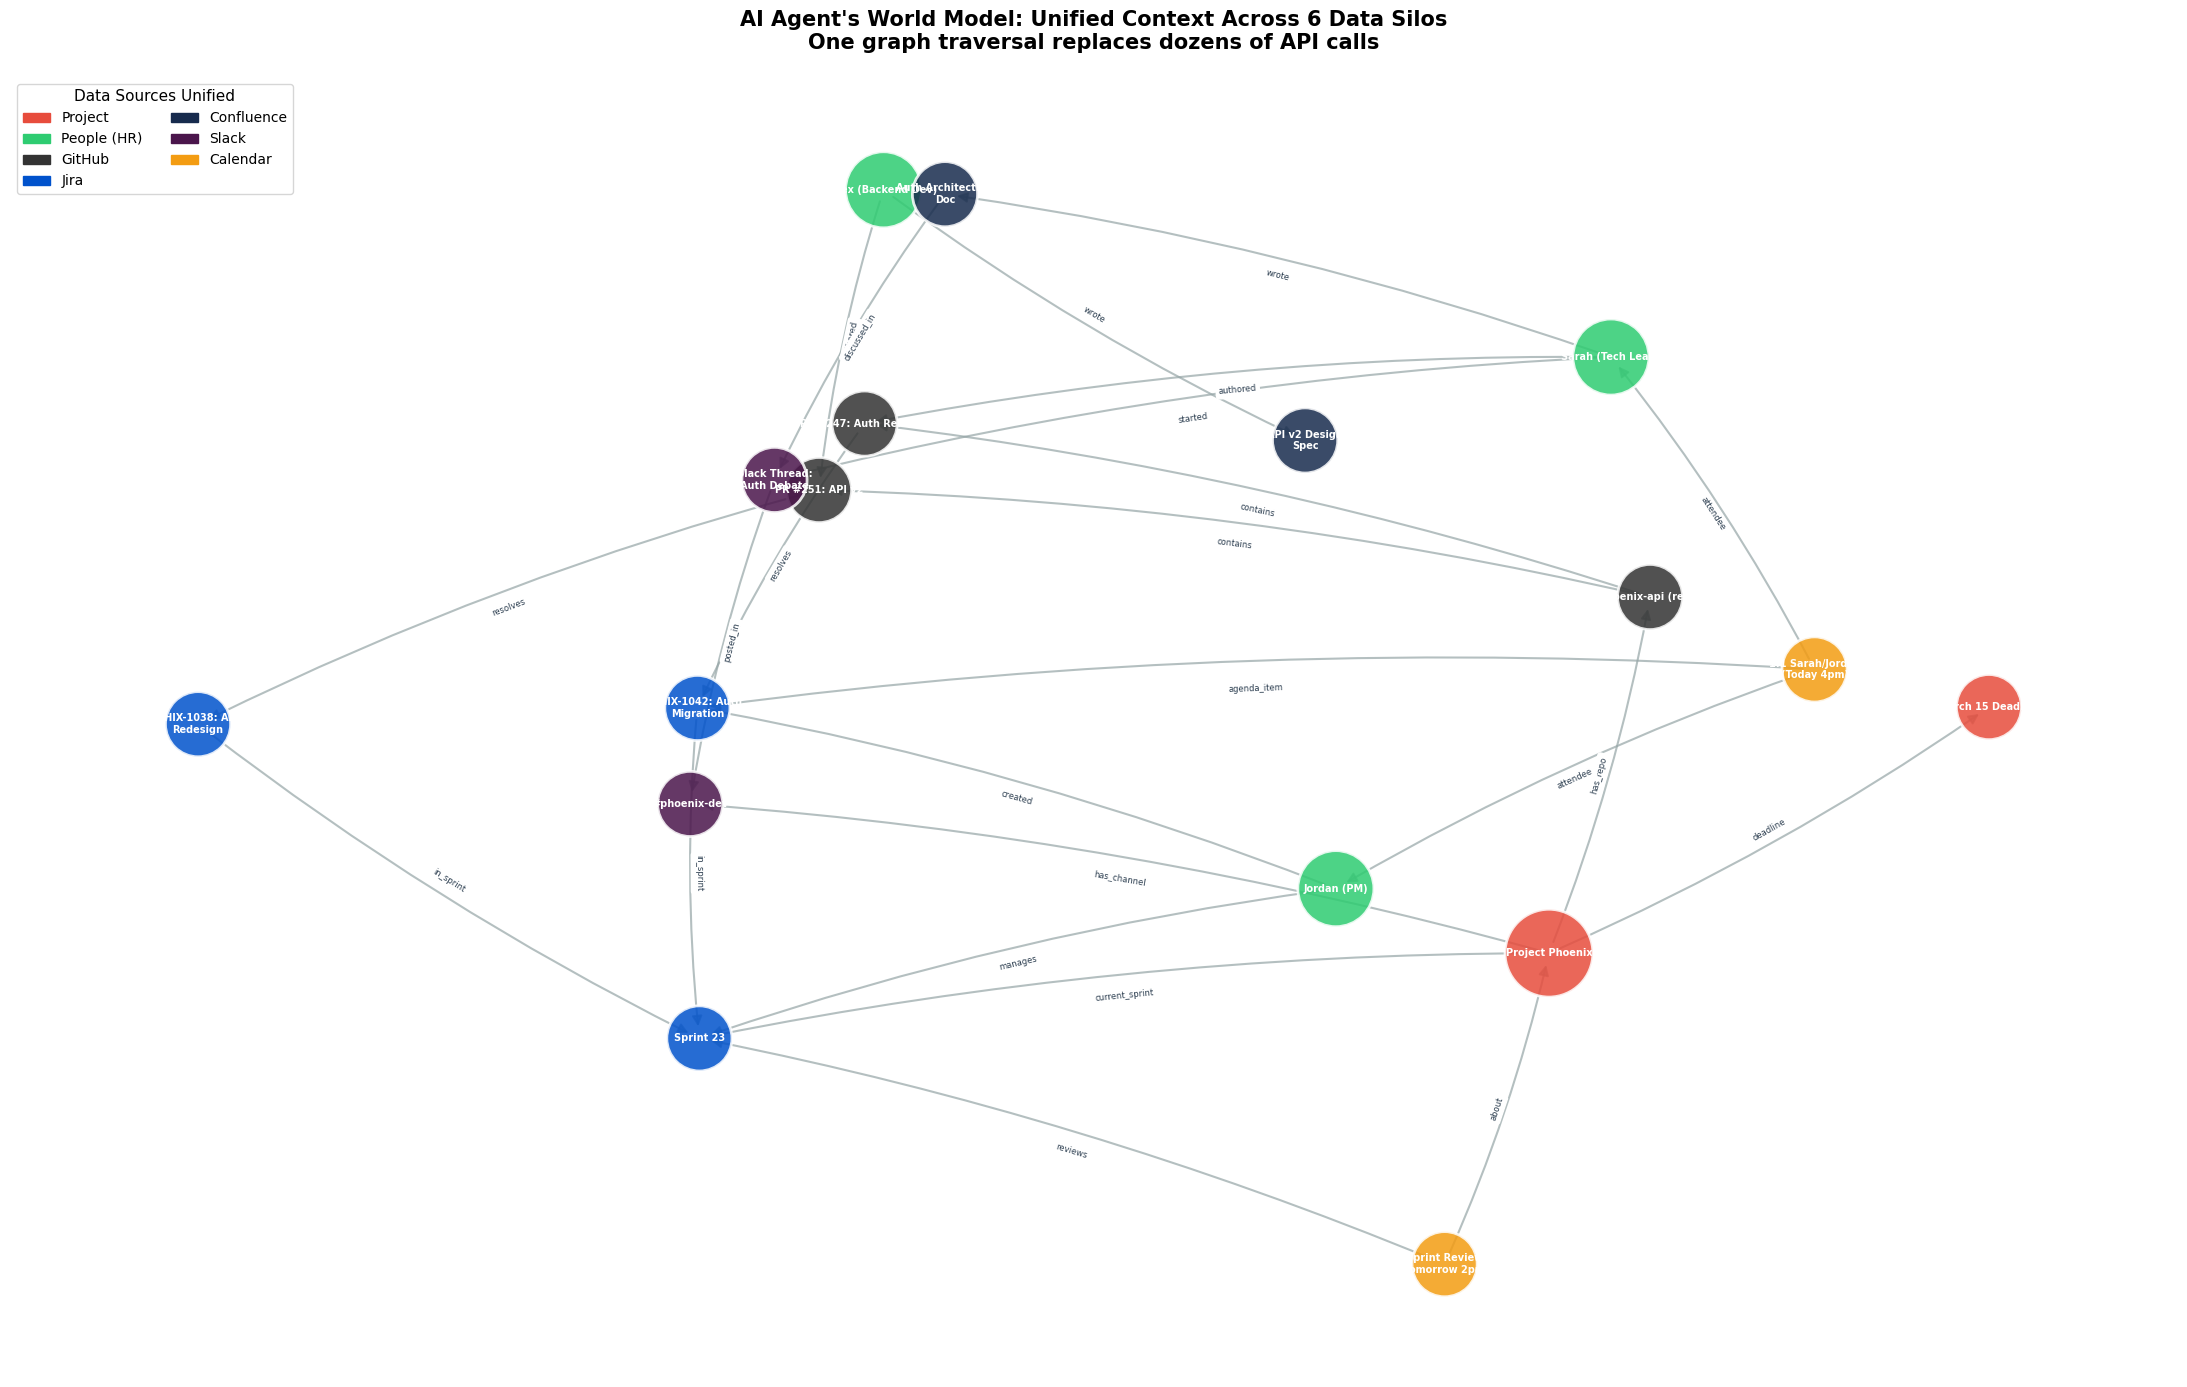

In [30]:
# --- Visualize the Agent's World Model ---

fig, ax = plt.subplots(1, 1, figsize=(22, 14))

pos = nx.kamada_kawai_layout(agent_kg)

source_colors = {
    "cross-system": "#e74c3c", "HR System": "#2ecc71", "GitHub": "#333333",
    "Jira": "#0052cc", "Confluence": "#172b4d", "Slack": "#4a154b",
    "Calendar": "#f39c12",
}

node_colors = [agent_entities[n]["color"] for n in agent_kg.nodes()]
node_sizes = [4000 if agent_entities[n]["type"] == "Project" else
              3000 if agent_entities[n]["type"] == "Person" else 2200
              for n in agent_kg.nodes()]

nx.draw_networkx_nodes(agent_kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(agent_kg, pos, font_size=7, font_weight="bold",
                         font_color="white", ax=ax)

nx.draw_networkx_edges(agent_kg, pos, edge_color="#95a5a6", arrows=True,
                        arrowsize=15, width=1.5, ax=ax,
                        connectionstyle="arc3,rad=0.05", alpha=0.7)

edge_labels = {(s, o): p for s, o, p in agent_relations}
nx.draw_networkx_edge_labels(agent_kg, pos, edge_labels=edge_labels,
                              font_size=6, font_color="#2c3e50", ax=ax)

# Data source legend
legend_items = [
    mpatches.Patch(color="#e74c3c", label="Project"),
    mpatches.Patch(color="#2ecc71", label="People (HR)"),
    mpatches.Patch(color="#333333", label="GitHub"),
    mpatches.Patch(color="#0052cc", label="Jira"),
    mpatches.Patch(color="#172b4d", label="Confluence"),
    mpatches.Patch(color="#4a154b", label="Slack"),
    mpatches.Patch(color="#f39c12", label="Calendar"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=10, ncol=2,
          title="Data Sources Unified", title_fontsize=11)

ax.set_title("AI Agent's World Model: Unified Context Across 6 Data Silos\n"
             "One graph traversal replaces dozens of API calls",
             fontsize=15, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

---

# Part 4: GraphRAG in Action — LLM + Knowledge Graph

Now let's build a real **GraphRAG pipeline** that:
1. Takes unstructured text documents
2. Uses an LLM to extract entities and relationships
3. Builds a Knowledge Graph automatically
4. Answers questions by combining graph traversal with LLM reasoning

This is the pattern behind Microsoft's GraphRAG, LangChain's graph integrations, and LlamaIndex's KG query engines.

In [36]:
# --- GraphRAG Pipeline: Step 1 — Sample Documents ---

documents = [
    {
        "id": "doc_1",
        "title": "TechCorp Q4 2025 Report",
        "text": """TechCorp, founded by Maria Chen in 2018, reported record revenue of $4.2 billion
in Q4 2025. The company's AI division, led by CTO James Park, launched NeuralEngine 3.0,
a breakthrough in natural language processing. TechCorp acquired DataFlow Systems for
$890 million to strengthen its cloud infrastructure. Maria Chen announced plans to
expand into the European market, opening offices in Berlin and London. The company's
main competitor, GlobalAI Inc, reported lower earnings of $2.1 billion for the same period."""
    },
    {
        "id": "doc_2",
        "title": "Industry Analysis: AI Market 2025",
        "text": """The AI market reached $450 billion in 2025, with TechCorp and GlobalAI Inc
as the dominant players. James Park's NeuralEngine 3.0 won the ACM Innovation Award.
DataFlow Systems, now a TechCorp subsidiary, provides cloud services to over 10,000
enterprises. GlobalAI Inc, led by CEO Robert Zhang, is focusing on autonomous vehicles
through its subsidiary AutoDrive Labs. Both companies are competing for a $2 billion
US Department of Defense contract for military AI systems. The Berlin office of TechCorp
is collaborating with the Max Planck Institute on quantum computing research."""
    },
    {
        "id": "doc_3",
        "title": "TechCorp Leadership Changes",
        "text": """Maria Chen stepped down as CEO of TechCorp, appointing James Park as her
successor. Chen will remain as Chairwoman of the Board. Park immediately restructured
the AI division, promoting Dr. Sarah Liu to VP of Research. Dr. Liu previously worked
at DeepMind and co-authored the influential paper 'Attention Mechanisms for Graph Neural
Networks' with Professor Alan Torres from MIT. TechCorp's Berlin office hired 200
researchers from the Max Planck Institute, raising concerns about brain drain in
Germany's academic sector."""
    },
]

print("📄 Sample Documents for GraphRAG Pipeline:\n")
for doc in documents:
    print(f"   [{doc['id']}] {doc['title']}")
    print(f"   {doc['text'][:100]}...")
    print()

📄 Sample Documents for GraphRAG Pipeline:

   [doc_1] TechCorp Q4 2025 Report
   TechCorp, founded by Maria Chen in 2018, reported record revenue of $4.2 billion
in Q4 2025. The com...

   [doc_2] Industry Analysis: AI Market 2025
   The AI market reached $450 billion in 2025, with TechCorp and GlobalAI Inc
as the dominant players. ...

   [doc_3] TechCorp Leadership Changes
   Maria Chen stepped down as CEO of TechCorp, appointing James Park as her
successor. Chen will remain...



In [37]:
# --- GraphRAG Pipeline: Step 2 — LLM-Powered Entity & Relationship Extraction ---

import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import List

# Uncomment and set your API key:
# os.environ["OPENAI_API_KEY"] = "sk-..."

EXTRACTION_PROMPT = """You are a knowledge graph extraction engine. Given a document,
extract ALL entities and relationships.

For each entity, provide:
- name: The canonical name (resolve coreferences — "the company" → "TechCorp")
- type: One of [Person, Organization, Product, Location, Event, Award, Amount, Date]

For each relationship, provide:
- source: Source entity name
- target: Target entity name
- relation: A concise verb phrase (e.g., "founded", "acquired", "located_in", "leads")
- source_doc: The document ID this was extracted from

Be thorough — extract EVERY entity and relationship mentioned."""


class Entity(BaseModel):
    name: str = Field(description="Canonical entity name")
    type: str = Field(description="Entity type")

class Relationship(BaseModel):
    source: str = Field(description="Source entity name")
    target: str = Field(description="Target entity name")
    relation: str = Field(description="Relationship type")

class ExtractionResult(BaseModel):
    entities: List[Entity]
    relationships: List[Relationship]


def extract_from_document(doc: dict, llm) -> ExtractionResult:
    """Use an LLM to extract entities and relationships from a document."""
    structured_llm = llm.with_structured_output(ExtractionResult)
    result = structured_llm.invoke([
        SystemMessage(content=EXTRACTION_PROMPT),
        HumanMessage(content=f"Document ID: {doc['id']}\nTitle: {doc['title']}\n\n{doc['text']}")
    ])
    return result


# Check if API key is available
api_key = os.environ.get("OPENAI_API_KEY", "")
USE_LLM = api_key and not api_key.startswith("sk-xxxx")

if USE_LLM:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    print("🤖 Using LLM for entity extraction...\n")

    all_entities = {}
    all_relationships = []

    for doc in documents:
        print(f"   Processing: {doc['title']}...")
        result = extract_from_document(doc, llm)

        for entity in result.entities:
            all_entities[entity.name] = entity.type

        for rel in result.relationships:
            all_relationships.append({
                "source": rel.source, "target": rel.target,
                "relation": rel.relation, "source_doc": doc["id"]
            })

    print(f"\n✅ Extracted {len(all_entities)} entities and {len(all_relationships)} relationships")

else:
    print("⚠️  No API key found — using pre-extracted entities and relationships.")
    print("   Set OPENAI_API_KEY to run live extraction.\n")

    all_entities = {
        "TechCorp": "Organization", "Maria Chen": "Person", "James Park": "Person",
        "NeuralEngine 3.0": "Product", "DataFlow Systems": "Organization",
        "GlobalAI Inc": "Organization", "Robert Zhang": "Person",
        "AutoDrive Labs": "Organization", "Dr. Sarah Liu": "Person",
        "Professor Alan Torres": "Person", "Berlin": "Location", "London": "Location",
        "MIT": "Organization", "DeepMind": "Organization",
        "Max Planck Institute": "Organization", "ACM Innovation Award": "Award",
        "US Dept. of Defense": "Organization",
        "$4.2B Revenue": "Amount", "$890M Acquisition": "Amount",
    }

    all_relationships = [
        {"source": "Maria Chen",     "target": "TechCorp",           "relation": "founded",          "source_doc": "doc_1"},
        {"source": "James Park",     "target": "TechCorp",           "relation": "CTO_of",           "source_doc": "doc_1"},
        {"source": "James Park",     "target": "NeuralEngine 3.0",   "relation": "launched",         "source_doc": "doc_1"},
        {"source": "TechCorp",       "target": "DataFlow Systems",   "relation": "acquired",         "source_doc": "doc_1"},
        {"source": "TechCorp",       "target": "Berlin",             "relation": "office_in",        "source_doc": "doc_1"},
        {"source": "TechCorp",       "target": "London",             "relation": "office_in",        "source_doc": "doc_1"},
        {"source": "TechCorp",       "target": "GlobalAI Inc",       "relation": "competes_with",    "source_doc": "doc_1"},
        {"source": "NeuralEngine 3.0","target": "ACM Innovation Award","relation": "won",            "source_doc": "doc_2"},
        {"source": "Robert Zhang",   "target": "GlobalAI Inc",       "relation": "CEO_of",           "source_doc": "doc_2"},
        {"source": "GlobalAI Inc",   "target": "AutoDrive Labs",     "relation": "subsidiary",       "source_doc": "doc_2"},
        {"source": "TechCorp",       "target": "US Dept. of Defense","relation": "competing_for_contract", "source_doc": "doc_2"},
        {"source": "GlobalAI Inc",   "target": "US Dept. of Defense","relation": "competing_for_contract", "source_doc": "doc_2"},
        {"source": "TechCorp",       "target": "Max Planck Institute","relation": "collaborates_with","source_doc": "doc_2"},
        {"source": "Maria Chen",     "target": "TechCorp",           "relation": "chairwoman_of",    "source_doc": "doc_3"},
        {"source": "James Park",     "target": "TechCorp",           "relation": "CEO_of",           "source_doc": "doc_3"},
        {"source": "Dr. Sarah Liu",  "target": "TechCorp",           "relation": "VP_Research_at",   "source_doc": "doc_3"},
        {"source": "Dr. Sarah Liu",  "target": "DeepMind",           "relation": "previously_at",    "source_doc": "doc_3"},
        {"source": "Dr. Sarah Liu",  "target": "Professor Alan Torres","relation": "co_authored_with","source_doc": "doc_3"},
        {"source": "Professor Alan Torres", "target": "MIT",         "relation": "professor_at",     "source_doc": "doc_3"},
        {"source": "TechCorp",       "target": "Max Planck Institute","relation": "hired_from",      "source_doc": "doc_3"},
    ]

    print(f"   Pre-loaded {len(all_entities)} entities and {len(all_relationships)} relationships")

🤖 Using LLM for entity extraction...

   Processing: TechCorp Q4 2025 Report...
   Processing: Industry Analysis: AI Market 2025...
   Processing: TechCorp Leadership Changes...

✅ Extracted 30 entities and 37 relationships


📊 GraphRAG Knowledge Graph Built:
   Nodes: 32
   Edges: 34

   Entity types:
     Organization: 8
     Person: 5
     Amount: 5
     Product: 4
     Location: 4
     Event: 2
     Unknown: 2
     Date: 1
     Award: 1


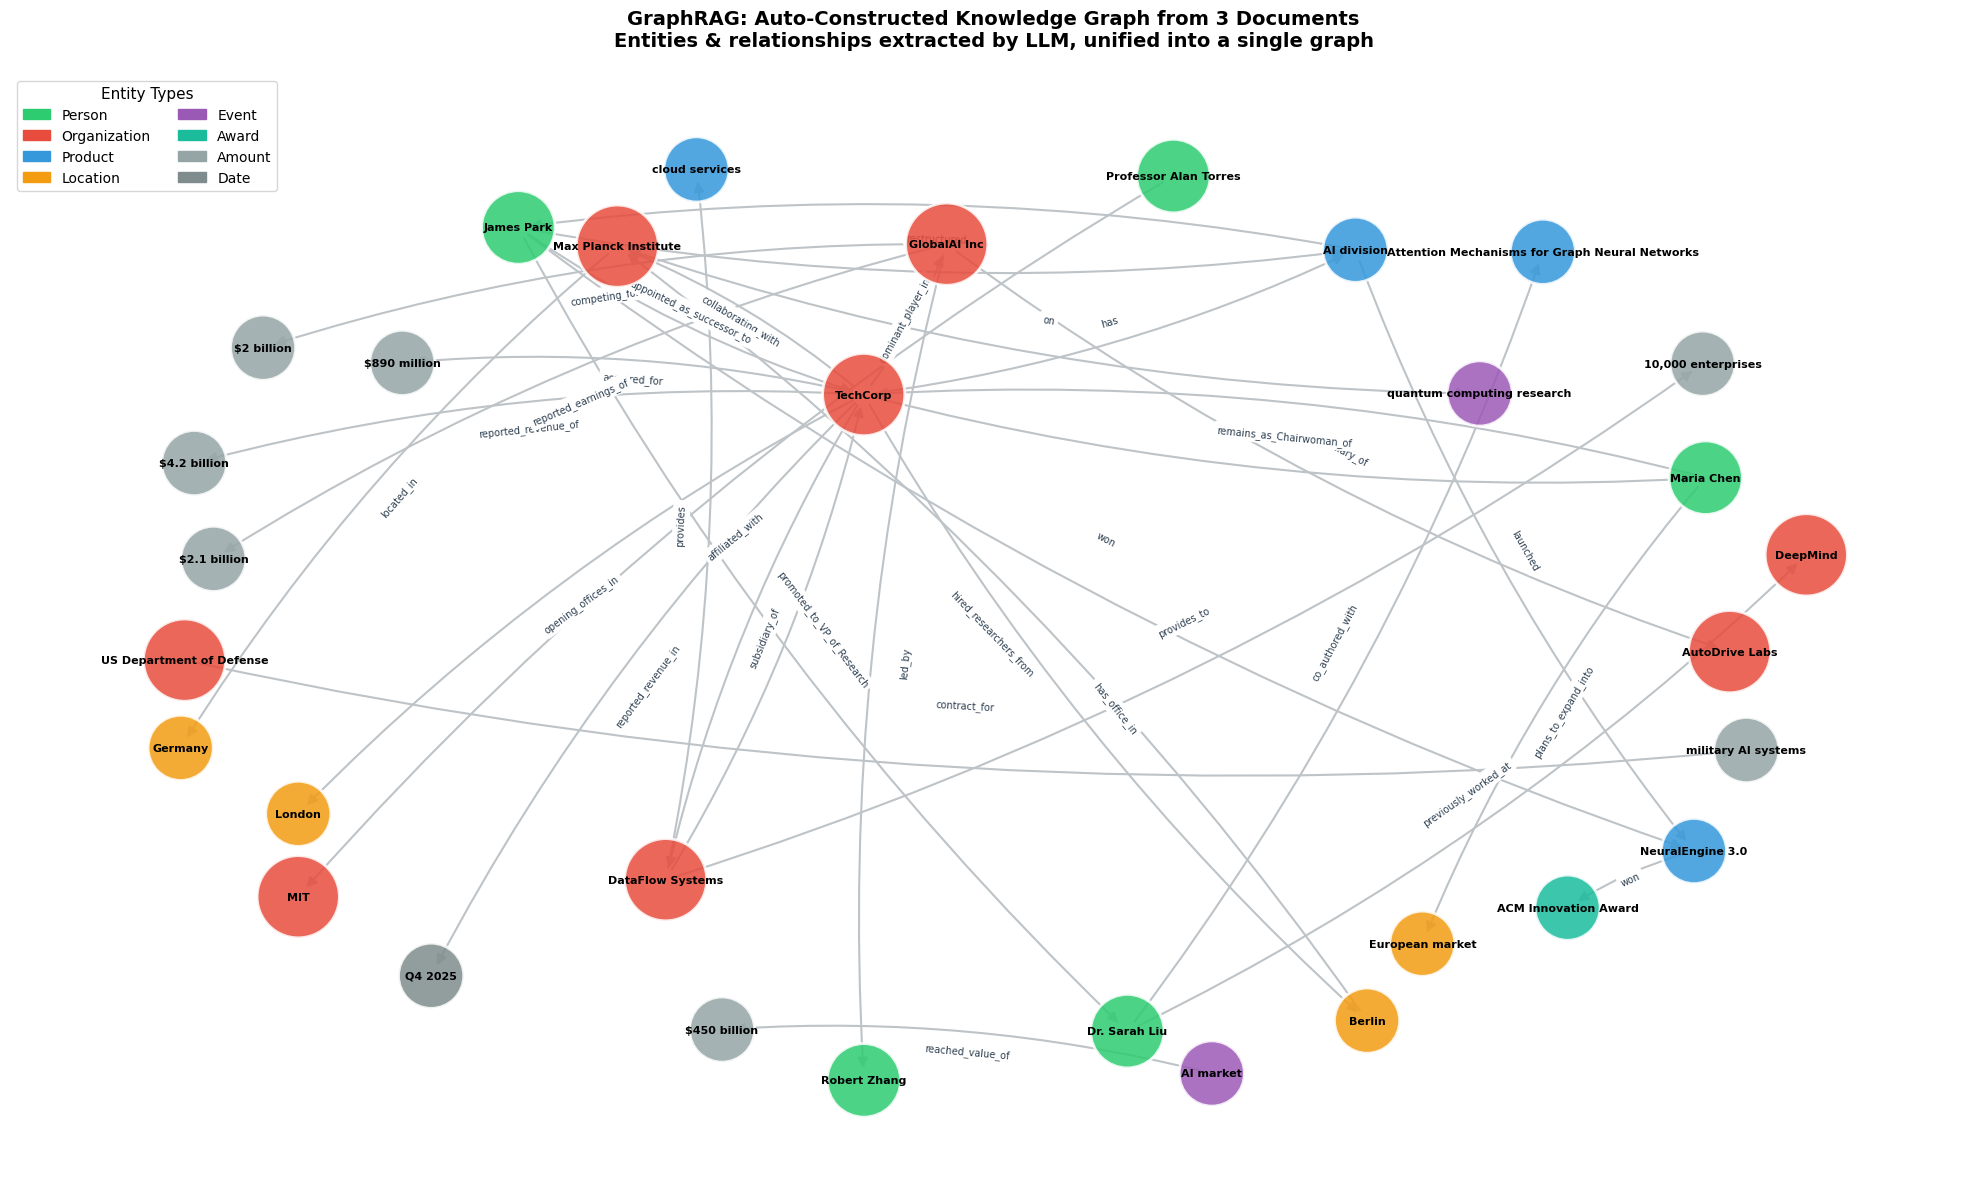

In [38]:
# --- GraphRAG Pipeline: Step 3 — Build the Knowledge Graph ---

graphrag_kg = nx.DiGraph()

type_colors = {
    "Person": "#2ecc71", "Organization": "#e74c3c", "Product": "#3498db",
    "Location": "#f39c12", "Event": "#9b59b6", "Award": "#1abc9c",
    "Amount": "#95a5a6", "Date": "#7f8c8d",
}

for name, etype in all_entities.items():
    graphrag_kg.add_node(name, type=etype, color=type_colors.get(etype, "#95a5a6"))

for rel in all_relationships:
    graphrag_kg.add_edge(rel["source"], rel["target"],
                          relation=rel["relation"], source_doc=rel["source_doc"])

print(f"📊 GraphRAG Knowledge Graph Built:")
print(f"   Nodes: {graphrag_kg.number_of_nodes()}")
print(f"   Edges: {graphrag_kg.number_of_edges()}")
print(f"\n   Entity types:")
type_counts = defaultdict(int)
for _, data in graphrag_kg.nodes(data=True):
    type_counts[data.get("type", "Unknown")] += 1
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"     {t}: {c}")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
pos = nx.spring_layout(graphrag_kg, seed=42, k=2.0)

node_colors = [graphrag_kg.nodes[n].get("color", "#95a5a6") for n in graphrag_kg.nodes()]
node_sizes = [3500 if graphrag_kg.nodes[n].get("type") == "Organization" else
              2800 if graphrag_kg.nodes[n].get("type") == "Person" else 2200
              for n in graphrag_kg.nodes()]

nx.draw_networkx_nodes(graphrag_kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(graphrag_kg, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(graphrag_kg, pos, edge_color="#bdc3c7", arrows=True,
                        arrowsize=15, width=1.5, ax=ax, connectionstyle="arc3,rad=0.08")

edge_labels = {(rel["source"], rel["target"]): rel["relation"] for rel in all_relationships}
nx.draw_networkx_edge_labels(graphrag_kg, pos, edge_labels=edge_labels,
                              font_size=7, font_color="#2c3e50", ax=ax)

legend_items = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items() if t in type_counts]
ax.legend(handles=legend_items, loc="upper left", fontsize=10, ncol=2,
          title="Entity Types", title_fontsize=11)

ax.set_title("GraphRAG: Auto-Constructed Knowledge Graph from 3 Documents\n"
             "Entities & relationships extracted by LLM, unified into a single graph",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

In [39]:
# --- GraphRAG Pipeline: Step 4 — Graph-Enhanced Question Answering ---

def graph_context_retrieval(graph, question: str, entities_dict: dict) -> str:
    """Retrieve relevant subgraph context for a question by finding
    mentioned entities and their neighborhoods."""

    mentioned = [e for e in entities_dict if e.lower() in question.lower()]

    if not mentioned:
        words = question.lower().split()
        for entity in entities_dict:
            for word in entity.lower().split():
                if word in words and len(word) > 3:
                    mentioned.append(entity)
                    break

    mentioned = list(set(mentioned))

    relevant_triples = []
    relevant_nodes = set()

    for entity in mentioned:
        if entity in graph:
            relevant_nodes.add(entity)
            for _, target, data in graph.out_edges(entity, data=True):
                relevant_triples.append(f"{entity} --[{data.get('relation', '?')}]--> {target}")
                relevant_nodes.add(target)
            for source, _, data in graph.in_edges(entity, data=True):
                relevant_triples.append(f"{source} --[{data.get('relation', '?')}]--> {entity}")
                relevant_nodes.add(source)

            for neighbor in relevant_nodes.copy():
                if neighbor in graph:
                    for _, t2, d2 in graph.out_edges(neighbor, data=True):
                        if t2 not in relevant_nodes:
                            relevant_triples.append(f"{neighbor} --[{d2.get('relation', '?')}]--> {t2}")

    context = "KNOWLEDGE GRAPH CONTEXT:\n"
    context += f"Entities found: {', '.join(mentioned)}\n\n"
    context += "Relevant relationships:\n"
    for triple in sorted(set(relevant_triples)):
        context += f"  - {triple}\n"

    return context


# Demo questions
demo_questions = [
    "What is the relationship between TechCorp and GlobalAI Inc?",
    "How is Dr. Sarah Liu connected to MIT?",
    "What happened with TechCorp's leadership?",
    "Which organizations are connected to the Berlin office?",
]

print("=" * 70)
print("🔍 GraphRAG: Graph-Enhanced Question Answering")
print("=" * 70)

for q in demo_questions:
    print(f"\n❓ Question: {q}\n")
    context = graph_context_retrieval(graphrag_kg, q, all_entities)
    print(context)

    if USE_LLM:
        response = llm.invoke([
            SystemMessage(content="You are a helpful analyst. Answer the question using ONLY "
                          "the knowledge graph context provided. Cite specific relationships."),
            HumanMessage(content=f"{context}\n\nQuestion: {q}")
        ])
        print(f"🤖 Answer: {response.content}\n")
    print("─" * 70)

🔍 GraphRAG: Graph-Enhanced Question Answering

❓ Question: What is the relationship between TechCorp and GlobalAI Inc?

KNOWLEDGE GRAPH CONTEXT:
Entities found: TechCorp, GlobalAI Inc

Relevant relationships:
  - AI division --[launched]--> NeuralEngine 3.0
  - DataFlow Systems --[provides]--> cloud services
  - DataFlow Systems --[provides_to]--> 10,000 enterprises
  - DataFlow Systems --[subsidiary_of]--> TechCorp
  - GlobalAI Inc --[competing_for]--> $2 billion
  - GlobalAI Inc --[led_by]--> Robert Zhang
  - GlobalAI Inc --[reported_earnings_of]--> $2.1 billion
  - GlobalAI Inc --[subsidiary_of]--> AutoDrive Labs
  - James Park --[appointed_as_successor_to]--> TechCorp
  - James Park --[promoted_to_VP_of_Research]--> Dr. Sarah Liu
  - James Park --[won]--> NeuralEngine 3.0
  - Maria Chen --[plans_to_expand_into]--> European market
  - Maria Chen --[remains_as_Chairwoman_of]--> TechCorp
  - Max Planck Institute --[located_in]--> Germany
  - Max Planck Institute --[on]--> quantum comp

---

# Part 5: Community Detection — The Secret Sauce of GraphRAG

One of GraphRAG's most powerful features is **community detection** — automatically finding clusters of related entities. This enables **"global queries"** like *"What are the main themes across all documents?"* that vanilla RAG completely fails at.

🏘️  Community Detection: Finding Thematic Clusters

📦 Community 1 (7 entities):
   • $4.2 billion [Amount]
   • $890 million [Amount]
   • European market [Location]
   • London [Location]
   • Maria Chen [Person]
   • Q4 2025 [Date]
   • TechCorp [Organization]

📦 Community 2 (7 entities):
   • ACM Innovation Award [Award]
   • AI division [Product]
   • Attention Mechanisms for Graph Neural Networks [Product]
   • DeepMind [Organization]
   • Dr. Sarah Liu [Person]
   • James Park [Person]
   • NeuralEngine 3.0 [Product]

📦 Community 3 (5 entities):
   • $2 billion [Amount]
   • $2.1 billion [Amount]
   • AutoDrive Labs [Organization]
   • GlobalAI Inc [Organization]
   • Robert Zhang [Person]

📦 Community 4 (4 entities):
   • Berlin [Location]
   • Germany [Location]
   • Max Planck Institute [Organization]
   • quantum computing research [Event]

📦 Community 5 (3 entities):
   • 10,000 enterprises [Amount]
   • DataFlow Systems [Organization]
   • cloud services [Product]

📦 Commun

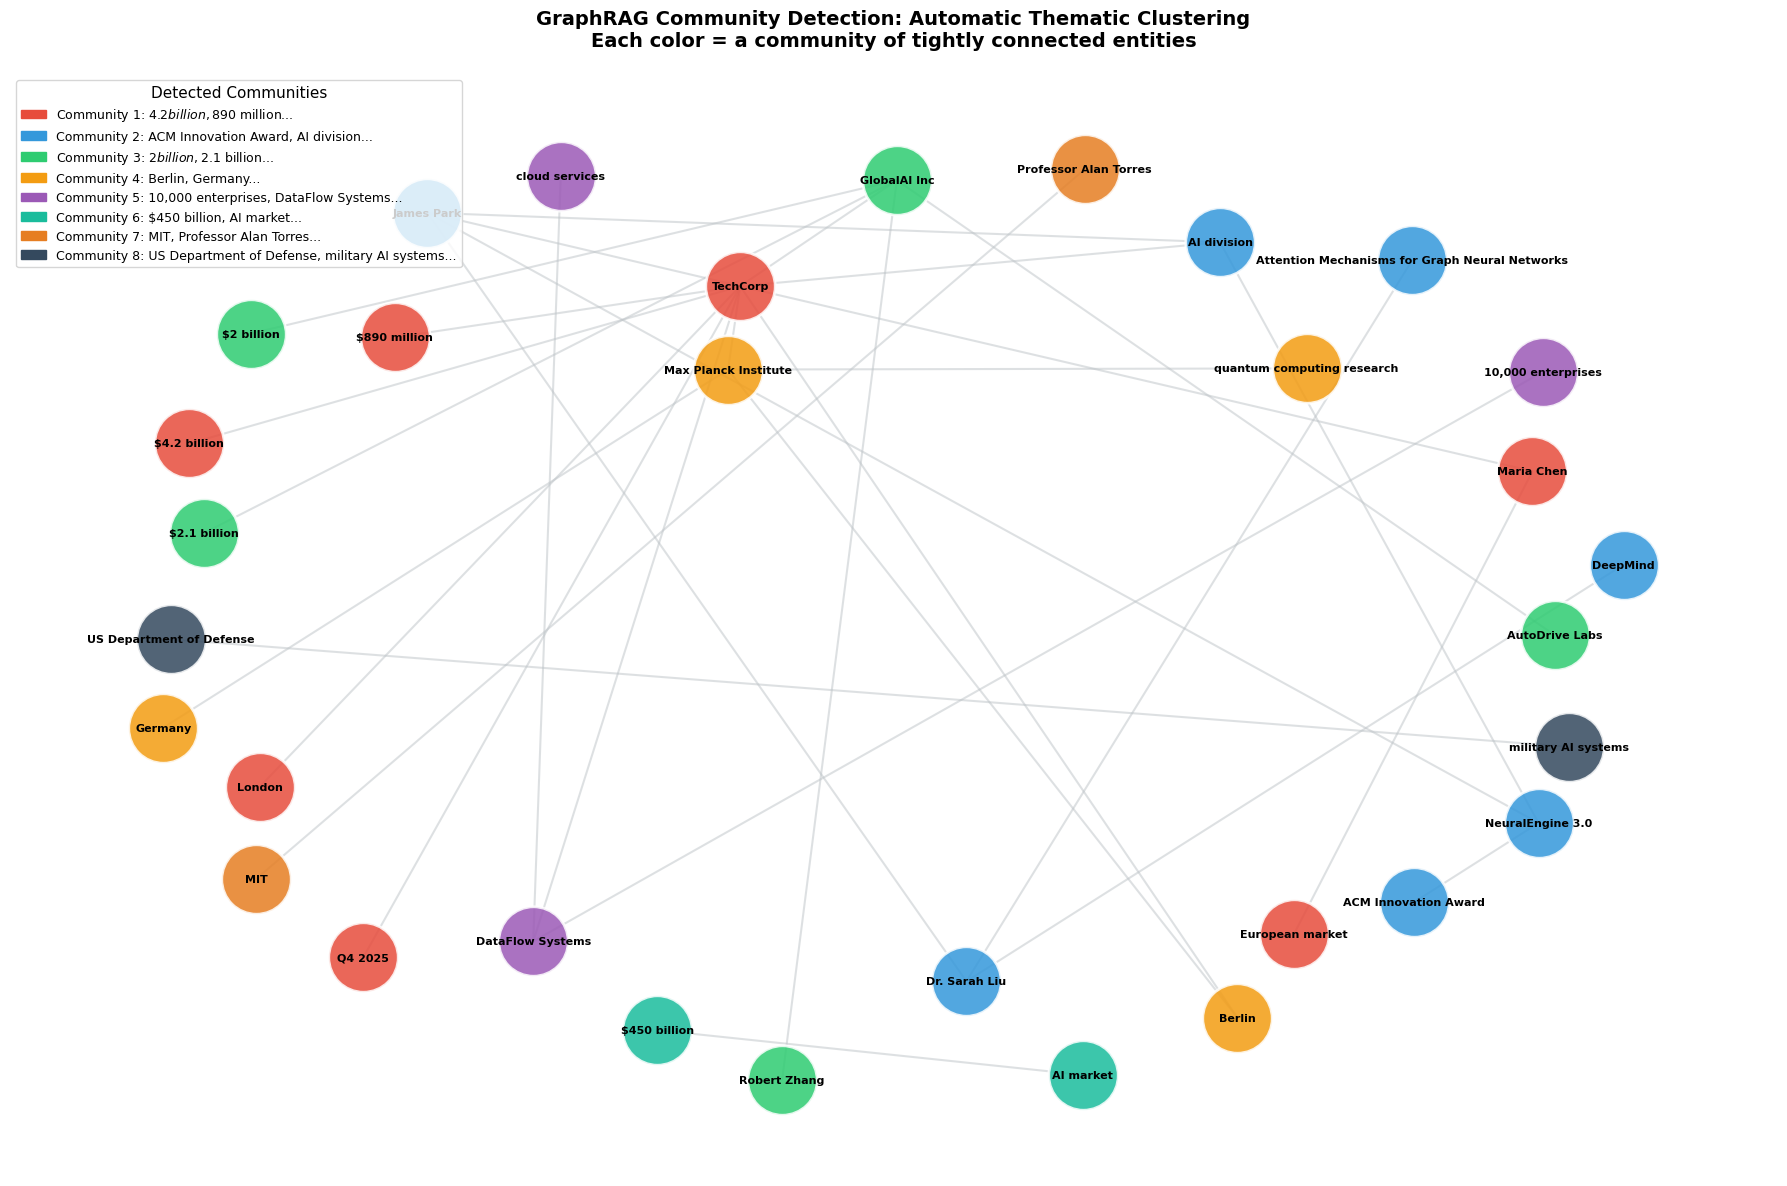


💡 These communities enable 'global queries' like:
   'What are the main themes across all documents?'
   Each community gets a summary → summaries are used for global reasoning.


In [40]:
# --- Community Detection on the GraphRAG Knowledge Graph ---

undirected = graphrag_kg.to_undirected()

communities = list(nx.community.greedy_modularity_communities(undirected))

community_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
                    "#1abc9c", "#e67e22", "#34495e"]

print("=" * 70)
print("🏘️  Community Detection: Finding Thematic Clusters")
print("=" * 70)

node_community = {}
for i, community in enumerate(communities):
    print(f"\n📦 Community {i+1} ({len(community)} entities):")
    for node in sorted(community):
        node_type = all_entities.get(node, "Unknown")
        print(f"   • {node} [{node_type}]")
        node_community[node] = i

print(f"\n📊 Found {len(communities)} communities (thematic clusters)")

# Visualize communities
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
pos = nx.spring_layout(undirected, seed=42, k=2.2)

for i, community in enumerate(communities):
    color = community_colors[i % len(community_colors)]
    nx.draw_networkx_nodes(undirected, pos, nodelist=list(community),
                            node_color=color, node_size=2500, alpha=0.85,
                            edgecolors="white", linewidths=2, ax=ax)

nx.draw_networkx_labels(undirected, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(undirected, pos, edge_color="#bdc3c7", width=1.5,
                        alpha=0.5, ax=ax)

legend_items = []
for i, community in enumerate(communities):
    color = community_colors[i % len(community_colors)]
    members = sorted(community)[:3]
    label = f"Community {i+1}: {', '.join(members[:2])}..."
    legend_items.append(mpatches.Patch(color=color, label=label))

ax.legend(handles=legend_items, loc="upper left", fontsize=9,
          title="Detected Communities", title_fontsize=11)

ax.set_title("GraphRAG Community Detection: Automatic Thematic Clustering\n"
             "Each color = a community of tightly connected entities",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\n💡 These communities enable 'global queries' like:")
print("   'What are the main themes across all documents?'")
print("   Each community gets a summary → summaries are used for global reasoning.")

---

# Part 6: Graph Analytics — Centrality & Influence

Beyond retrieval, Knowledge Graphs support powerful **analytical queries** that reveal the structure of information. Who are the most influential entities? Which nodes are bridges between communities?

📊 Graph Analytics: Entity Importance Scores

Entity                         Type              Degree   Between.   PageRank
───────────────────────────────────────────────────────────────────────────
ACM Innovation Award           Award              0.032      0.000     0.0565
Max Planck Institute           Organization       0.129      0.013     0.0458
TechCorp                       Organization       0.419      0.087     0.0458
NeuralEngine 3.0               Product            0.097      0.005     0.0419
quantum computing research     Event              0.032      0.000     0.0404
Germany                        Location           0.032      0.000     0.0404
MIT                            Organization       0.032      0.000     0.0386
$450 billion                   Unknown            0.032      0.000     0.0386
military AI systems            Unknown            0.032      0.000     0.0386
James Park                     Person             0.161      0.033     0.0345

💡 INSIGHTS:
   • Mos

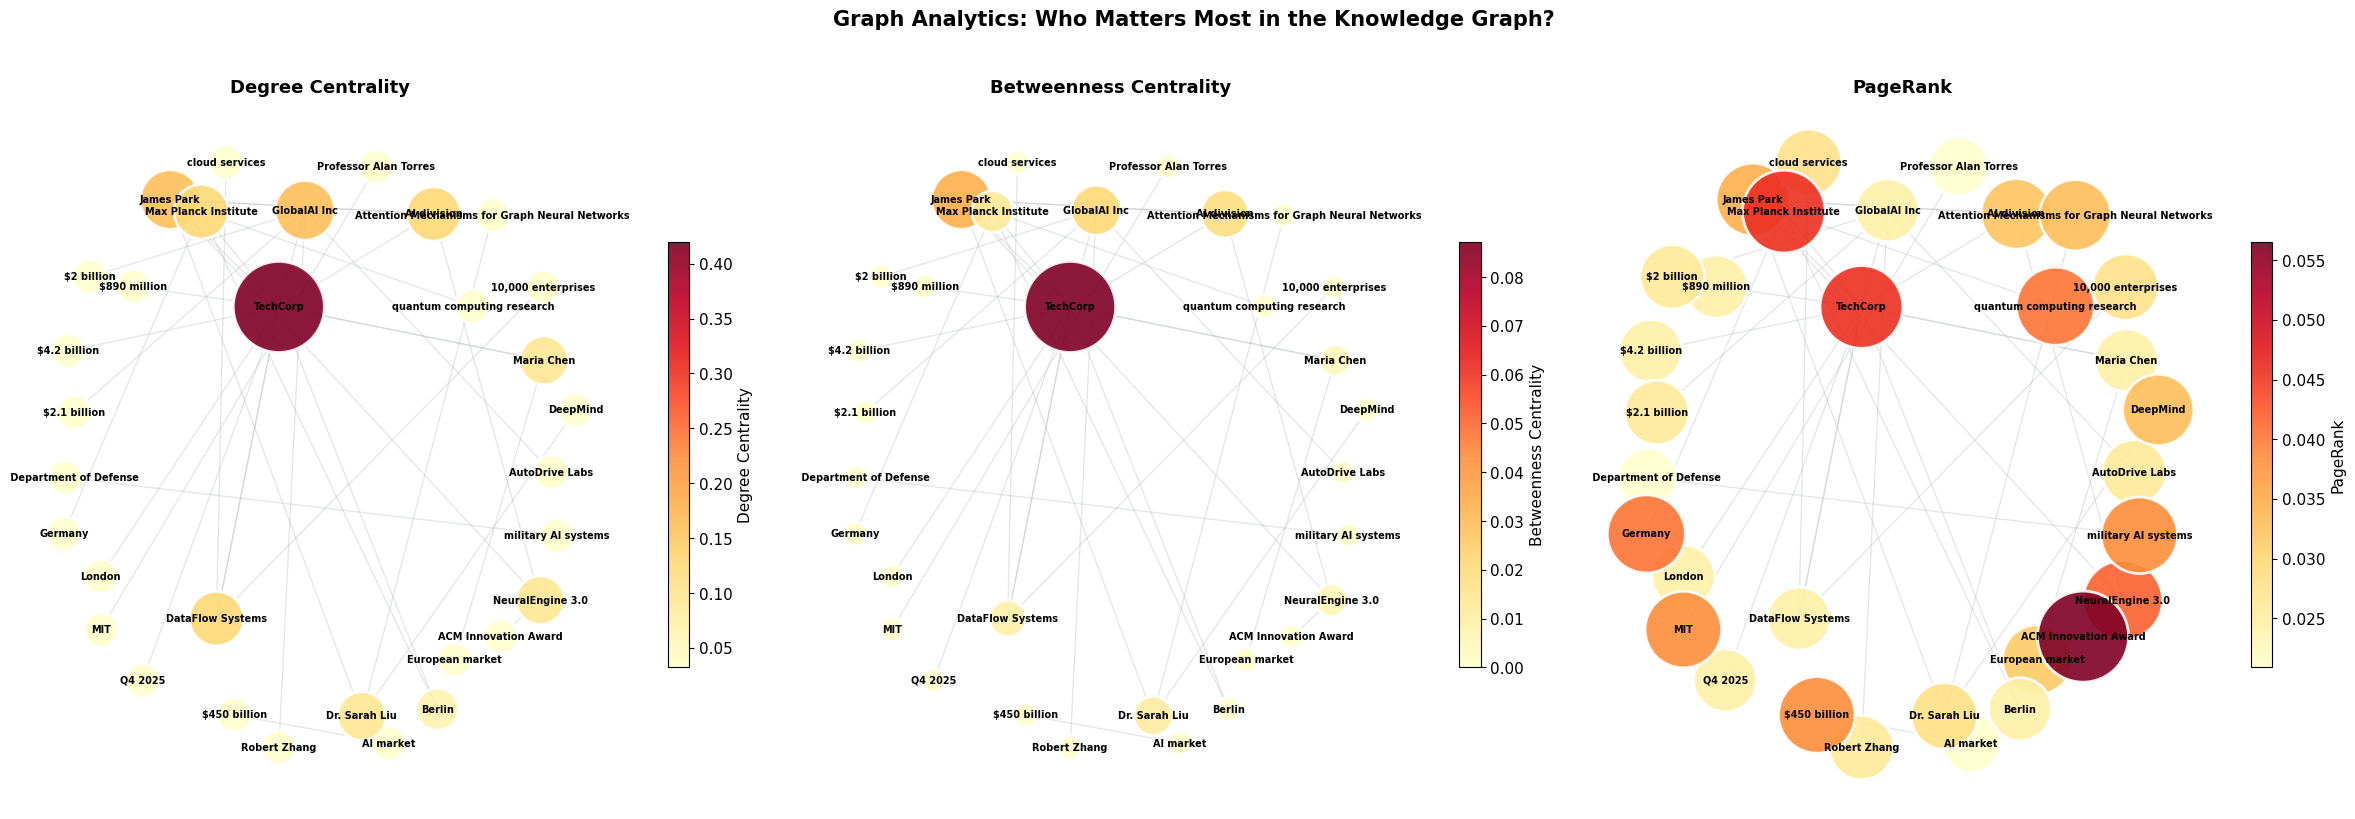

In [42]:
# --- Graph Analytics: Centrality Measures ---

degree_centrality = nx.degree_centrality(graphrag_kg)
betweenness = nx.betweenness_centrality(graphrag_kg)
pagerank = nx.pagerank(graphrag_kg)

print("=" * 70)
print("📊 Graph Analytics: Entity Importance Scores")
print("=" * 70)

metrics = []
for node in graphrag_kg.nodes():
    metrics.append({
        "entity": node,
        "type": all_entities.get(node, "Unknown"),
        "degree": degree_centrality[node],
        "betweenness": betweenness[node],
        "pagerank": pagerank[node],
    })

metrics.sort(key=lambda x: x["pagerank"], reverse=True)

print(f"\n{'Entity':<30} {'Type':<15} {'Degree':>8} {'Between.':>10} {'PageRank':>10}")
print("─" * 75)
for m in metrics[:10]:
    print(f"{m['entity']:<30} {m['type']:<15} {m['degree']:>8.3f} {m['betweenness']:>10.3f} {m['pagerank']:>10.4f}")

print("\n💡 INSIGHTS:")
print(f"   • Most connected (degree): {metrics[0]['entity']}")
most_between = max(metrics, key=lambda x: x["betweenness"])
print(f"   • Biggest bridge (betweenness): {most_between['entity']}")
print(f"   • Most influential (PageRank): {metrics[0]['entity']}")

# Visualization with node size proportional to PageRank
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, (metric_name, metric_dict) in enumerate([
    ("Degree Centrality", degree_centrality),
    ("Betweenness Centrality", betweenness),
    ("PageRank", pagerank),
]):
    ax = axes[idx]
    pos = nx.spring_layout(graphrag_kg, seed=42, k=2.0)

    max_val = max(metric_dict.values()) if max(metric_dict.values()) > 0 else 1
    sizes = [300 + 4000 * (metric_dict[n] / max_val) for n in graphrag_kg.nodes()]
    colors = [metric_dict[n] for n in graphrag_kg.nodes()]

    nodes = nx.draw_networkx_nodes(graphrag_kg, pos, node_size=sizes,
                                    node_color=colors, cmap=plt.cm.YlOrRd,
                                    alpha=0.9, edgecolors="white", linewidths=2, ax=ax)
    nx.draw_networkx_labels(graphrag_kg, pos, font_size=7, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(graphrag_kg, pos, edge_color="#bdc3c7", arrows=False,
                            width=1, alpha=0.4, ax=ax)

    plt.colorbar(nodes, ax=ax, shrink=0.6, label=metric_name)
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Graph Analytics: Who Matters Most in the Knowledge Graph?",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

# Part 7: Code Intelligence — Codebase as a Knowledge Graph

## The Idea

What if you could **talk to your codebase** like a senior engineer who knows every class, method, and dependency?

Traditional code search is keyword-based — it finds *strings*, not *meaning*. But by parsing source code into its **Abstract Syntax Tree (AST)** and loading the structure into a Knowledge Graph, we can capture:

- **Class hierarchies** (inheritance, interfaces)
- **Method signatures** and call chains
- **Field types** and dependencies
- **Package structure** and layered architecture

Then we give an LLM access to this graph as a **tool**, enabling it to traverse relationships and answer architectural questions that no grep command could.

## What We'll Build

| Step | What Happens |
|---|---|
| **1. Parse** | Walk a sample Java e-commerce project and extract AST-level structures |
| **2. Graph** | Load classes, methods, fields, and relationships into a NetworkX Knowledge Graph |
| **3. Visualize** | See the architecture as a color-coded graph |
| **4. Query** | Give an LLM a `search_codebase` tool backed by the graph — ask questions in plain English |

In [ ]:
# --- Step 1: Parse Java Source Files into AST Structures ---

import re
import os
from pathlib import Path

JAVA_PROJECT_ROOT = Path("sample-java-project/src/main/java")

def parse_java_file(filepath: Path) -> dict:
    """Lightweight regex-based Java parser that extracts structural AST info."""
    content = filepath.read_text()
    result = {
        "file": str(filepath),
        "package": "",
        "imports": [],
        "classes": [],
        "interfaces": [],
        "enums": [],
    }

    pkg_match = re.search(r"package\s+([\w.]+);", content)
    if pkg_match:
        result["package"] = pkg_match.group(1)

    result["imports"] = re.findall(r"import\s+([\w.]+);", content)

    # Parse class/interface/enum declarations
    type_pattern = re.compile(
        r"(public\s+)?(abstract\s+)?(class|interface|enum)\s+(\w+)"
        r"(?:\s+extends\s+(\w+))?"
        r"(?:\s+implements\s+([\w\s,]+))?"
    )
    for match in type_pattern.finditer(content):
        is_abstract = match.group(2) is not None
        kind = match.group(3)
        name = match.group(4)
        extends = match.group(5)
        implements_raw = match.group(6)
        implements = [i.strip() for i in implements_raw.split(",")] if implements_raw else []

        type_info = {
            "name": name,
            "kind": kind,
            "is_abstract": is_abstract,
            "extends": extends,
            "implements": implements,
            "methods": [],
            "fields": [],
        }

        # Extract the body of this type
        start = match.end()
        brace_count = 0
        body_start = content.index("{", start)
        body_end = body_start
        for i in range(body_start, len(content)):
            if content[i] == "{":
                brace_count += 1
            elif content[i] == "}":
                brace_count -= 1
                if brace_count == 0:
                    body_end = i
                    break
        body = content[body_start:body_end + 1]

        # Extract methods
        method_pattern = re.compile(
            r"(public|private|protected)?\s*(static\s+)?"
            r"([\w<>\[\],\s]+?)\s+(\w+)\s*\(([^)]*)\)\s*\{"
        )
        for m in method_pattern.finditer(body):
            visibility = m.group(1) or "package-private"
            is_static = m.group(2) is not None
            return_type = m.group(3).strip()
            method_name = m.group(4)
            params_raw = m.group(5).strip()
            params = []
            if params_raw:
                for p in params_raw.split(","):
                    parts = p.strip().rsplit(" ", 1)
                    if len(parts) == 2:
                        params.append({"type": parts[0].strip(), "name": parts[1].strip()})

            type_info["methods"].append({
                "name": method_name,
                "return_type": return_type,
                "visibility": visibility,
                "is_static": is_static,
                "parameters": params,
            })

        # Extract fields
        field_pattern = re.compile(
            r"(public|private|protected)\s+(static\s+)?(final\s+)?"
            r"([\w<>\[\],\s]+?)\s+(\w+)\s*[;=]"
        )
        for f in field_pattern.finditer(body):
            if f.group(4).strip() not in ("return", "new", "throw", "if", "else"):
                type_info["fields"].append({
                    "name": f.group(5),
                    "type": f.group(4).strip(),
                    "visibility": f.group(1),
                    "is_static": f.group(2) is not None,
                    "is_final": f.group(3) is not None,
                })

        if kind == "class":
            result["classes"].append(type_info)
        elif kind == "interface":
            result["interfaces"].append(type_info)
        elif kind == "enum":
            result["enums"].append(type_info)

    return result


# Parse all Java files
java_files = sorted(JAVA_PROJECT_ROOT.rglob("*.java"))
parsed_files = [parse_java_file(f) for f in java_files]

print(f"📂 Parsed {len(parsed_files)} Java files from: {JAVA_PROJECT_ROOT}\n")
for pf in parsed_files:
    types = pf["classes"] + pf["interfaces"] + pf["enums"]
    for t in types:
        methods = [m["name"] for m in t["methods"]]
        fields = [f["name"] for f in t["fields"]]
        print(f"   {t['kind']:>9} {t['name']:<25} "
              f"methods={len(methods):<3} fields={len(fields):<3} "
              f"extends={t['extends'] or '—'}")


In [ ]:
# --- Step 2: Build a Code Knowledge Graph from Parsed AST ---

code_kg = nx.DiGraph()

LAYER_COLORS = {
    "controller": "#3498db",
    "service":    "#2ecc71",
    "model":      "#e74c3c",
    "repository": "#9b59b6",
    "util":       "#f39c12",
}

def get_layer(package: str) -> str:
    for layer in LAYER_COLORS:
        if layer in package:
            return layer
    return "model"

for pf in parsed_files:
    package = pf["package"]
    layer = get_layer(package)

    code_kg.add_node(package, type="package", layer=layer, color="#95a5a6")

    for t in pf["classes"] + pf["interfaces"] + pf["enums"]:
        fqn = f"{package}.{t['name']}"
        code_kg.add_node(fqn, type=t["kind"], layer=layer,
                         color=LAYER_COLORS.get(layer, "#bdc3c7"),
                         is_abstract=t.get("is_abstract", False),
                         short_name=t["name"])

        code_kg.add_edge(fqn, package, relation="belongs_to_package")

        if t["extends"]:
            parent_fqn = t["extends"]
            for pf2 in parsed_files:
                for t2 in pf2["classes"] + pf2["interfaces"] + pf2["enums"]:
                    if t2["name"] == t["extends"]:
                        parent_fqn = f"{pf2['package']}.{t2['name']}"
                        break
            code_kg.add_edge(fqn, parent_fqn, relation="extends")

        for iface in t["implements"]:
            iface_fqn = iface
            for pf2 in parsed_files:
                for t2 in pf2["interfaces"]:
                    if t2["name"] == iface:
                        iface_fqn = f"{pf2['package']}.{t2['name']}"
                        break
            code_kg.add_edge(fqn, iface_fqn, relation="implements")

        for method in t["methods"]:
            method_node = f"{fqn}.{method['name']}()"
            code_kg.add_node(method_node, type="method",
                             return_type=method["return_type"],
                             visibility=method["visibility"],
                             is_static=method["is_static"],
                             color="#ecf0f1",
                             short_name=f"{method['name']}()")
            code_kg.add_edge(method_node, fqn, relation="defined_in")

            for param in method["parameters"]:
                param_type = param["type"]
                for pf2 in parsed_files:
                    for t2 in pf2["classes"] + pf2["interfaces"] + pf2["enums"]:
                        if t2["name"] == param_type:
                            target_fqn = f"{pf2['package']}.{t2['name']}"
                            code_kg.add_edge(method_node, target_fqn, relation="takes_parameter")
                            break

            ret = method["return_type"]
            for pf2 in parsed_files:
                for t2 in pf2["classes"] + pf2["interfaces"] + pf2["enums"]:
                    if t2["name"] == ret:
                        target_fqn = f"{pf2['package']}.{t2['name']}"
                        code_kg.add_edge(method_node, target_fqn, relation="returns")
                        break

        for field in t["fields"]:
            field_type = field["type"]
            for pf2 in parsed_files:
                for t2 in pf2["classes"] + pf2["interfaces"] + pf2["enums"]:
                    if t2["name"] == field_type or t2["name"] in field_type:
                        target_fqn = f"{pf2['package']}.{t2['name']}"
                        code_kg.add_edge(fqn, target_fqn,
                                         relation="has_field",
                                         field_name=field["name"])
                        break

# Add cross-layer dependency edges (service → repository, controller → service)
for pf in parsed_files:
    for t in pf["classes"]:
        fqn = f"{pf['package']}.{t['name']}"
        for field in t["fields"]:
            for pf2 in parsed_files:
                for t2 in pf2["classes"] + pf2["interfaces"]:
                    if t2["name"] == field["type"]:
                        target_fqn = f"{pf2['package']}.{t2['name']}"
                        code_kg.add_edge(fqn, target_fqn, relation="depends_on")

type_counts = defaultdict(int)
for _, data in code_kg.nodes(data=True):
    type_counts[data.get("type", "unknown")] += 1

rel_counts = defaultdict(int)
for _, _, data in code_kg.edges(data=True):
    rel_counts[data.get("relation", "unknown")] += 1

print("=" * 70)
print("🏗️  Code Knowledge Graph Built!")
print("=" * 70)
print(f"\n   Total nodes: {code_kg.number_of_nodes()}")
print(f"   Total edges: {code_kg.number_of_edges()}\n")
print("   Node types:")
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"     {t:<15} {c}")
print("\n   Relationship types:")
for r, c in sorted(rel_counts.items(), key=lambda x: -x[1]):
    print(f"     {r:<25} {c}")

In [ ]:
# --- Step 3: Visualize the Code Knowledge Graph ---

# Show only classes/interfaces/enums (skip individual methods for readability)
viz_nodes = [n for n, d in code_kg.nodes(data=True) if d.get("type") in ("class", "interface", "enum")]
viz_graph = code_kg.subgraph(viz_nodes).copy()

fig, ax = plt.subplots(1, 1, figsize=(16, 10))

pos = nx.spring_layout(viz_graph, seed=42, k=3.5, iterations=60)

for layer_name, color in LAYER_COLORS.items():
    layer_nodes = [n for n in viz_graph.nodes() if viz_graph.nodes[n].get("layer") == layer_name]
    if layer_nodes:
        nx.draw_networkx_nodes(viz_graph, pos, nodelist=layer_nodes,
                               node_color=color, node_size=1200,
                               alpha=0.9, edgecolors="white", linewidths=2, ax=ax)

labels = {n: viz_graph.nodes[n].get("short_name", n.split(".")[-1]) for n in viz_graph.nodes()}
nx.draw_networkx_labels(viz_graph, pos, labels=labels, font_size=8, font_weight="bold", ax=ax)

edge_styles = {
    "extends": ("#e74c3c", 2.5, "solid"),
    "implements": ("#9b59b6", 2.0, "dashed"),
    "depends_on": ("#7f8c8d", 1.2, "dotted"),
    "has_field": ("#3498db", 1.0, "dotted"),
}

for rel_type, (color, width, style) in edge_styles.items():
    rel_edges = [(u, v) for u, v, d in viz_graph.edges(data=True) if d.get("relation") == rel_type]
    if rel_edges:
        nx.draw_networkx_edges(viz_graph, pos, edgelist=rel_edges,
                               edge_color=color, width=width, style=style,
                               arrows=False, alpha=0.6, ax=ax)

legend_patches = [mpatches.Patch(color=c, label=l.title()) for l, c in LAYER_COLORS.items()]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="── extends"))
legend_patches.append(mpatches.Patch(color="#9b59b6", label="┄┄ implements"))
legend_patches.append(mpatches.Patch(color="#7f8c8d", label="···· depends_on"))
ax.legend(handles=legend_patches, loc="upper left", fontsize=10, ncol=2)

ax.set_title("Java E-Commerce Codebase — Architecture as a Knowledge Graph\n"
             "Colors = architectural layers | Edges = code relationships",
             fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# --- Step 4: LLM + GraphRAG Tool for Codebase Q&A ---

def search_codebase(query: str) -> str:
    """Graph-powered codebase search tool.
    Supports queries about classes, methods, inheritance, dependencies, and architecture."""

    query_lower = query.lower()
    results = []

    # Find classes/interfaces/enums matching the query
    matching_types = []
    for node, data in code_kg.nodes(data=True):
        if data.get("type") in ("class", "interface", "enum"):
            short = data.get("short_name", node.split(".")[-1])
            if short.lower() in query_lower or query_lower in short.lower():
                matching_types.append((node, data))

    # If asking about inheritance or hierarchy
    if any(kw in query_lower for kw in ["extend", "inherit", "parent", "hierarchy", "subclass"]):
        for node, data in code_kg.nodes(data=True):
            if data.get("type") in ("class", "interface", "enum"):
                short = data.get("short_name", node.split(".")[-1])
                parents = [v for _, v, d in code_kg.edges(node, data=True) if d.get("relation") == "extends"]
                children = [u for u, _, d in code_kg.edges(data=True) if d.get("relation") == "extends" and _ == node]
                if parents or children:
                    info = f"{short}"
                    if parents:
                        info += f" extends {', '.join(p.split('.')[-1] for p in parents)}"
                    if children:
                        info += f" ← subclassed by {', '.join(c.split('.')[-1] for c in children)}"
                    results.append(info)

    # If asking about dependencies or what uses what
    elif any(kw in query_lower for kw in ["depend", "uses", "calls", "inject", "need"]):
        for node, data in code_kg.nodes(data=True):
            if data.get("type") in ("class", "interface"):
                short = data.get("short_name", node.split(".")[-1])
                deps = [v.split(".")[-1] for _, v, d in code_kg.edges(node, data=True)
                        if d.get("relation") in ("depends_on", "has_field")]
                if deps and (not matching_types or node in [m[0] for m in matching_types]):
                    results.append(f"{short} depends on: {', '.join(set(deps))}")

    # If asking about methods
    elif any(kw in query_lower for kw in ["method", "function", "api", "endpoint"]):
        for node, data in code_kg.nodes(data=True):
            if data.get("type") == "method":
                parent_class = [v for _, v, d in code_kg.edges(node, data=True) if d.get("relation") == "defined_in"]
                class_name = parent_class[0].split(".")[-1] if parent_class else "?"
                if matching_types:
                    if not any(class_name == mt[1].get("short_name") for mt in matching_types):
                        continue
                ret = data.get("return_type", "void")
                vis = data.get("visibility", "")
                results.append(f"{class_name}.{data.get('short_name', node.split('.')[-1])} → {ret} [{vis}]")

    # If asking about layers or architecture
    elif any(kw in query_lower for kw in ["layer", "architect", "package", "structure"]):
        layers = defaultdict(list)
        for node, data in code_kg.nodes(data=True):
            if data.get("type") in ("class", "interface", "enum"):
                layers[data.get("layer", "?")].append(data.get("short_name", node.split(".")[-1]))
        for layer, classes in sorted(layers.items()):
            results.append(f"[{layer.upper()}] {', '.join(classes)}")

    # If asking about a specific class
    elif matching_types:
        for node, data in matching_types:
            short = data.get("short_name", node.split(".")[-1])
            info_parts = [f"**{short}** ({data.get('type')}) in {data.get('layer')} layer"]

            parents = [v.split(".")[-1] for _, v, d in code_kg.edges(node, data=True) if d.get("relation") == "extends"]
            if parents:
                info_parts.append(f"  extends: {', '.join(parents)}")

            deps = [v.split(".")[-1] for _, v, d in code_kg.edges(node, data=True) if d.get("relation") in ("depends_on", "has_field")]
            if deps:
                info_parts.append(f"  depends on: {', '.join(set(deps))}")

            methods = [u for u, _, d in code_kg.edges(data=True) if d.get("relation") == "defined_in" and _ == node]
            if methods:
                method_names = [code_kg.nodes[m].get("short_name", m.split(".")[-1]) for m in methods]
                info_parts.append(f"  methods: {', '.join(method_names)}")

            results.append("\n".join(info_parts))

    # General search fallback
    else:
        for node, data in code_kg.nodes(data=True):
            short = data.get("short_name", node.split(".")[-1])
            if any(word in short.lower() for word in query_lower.split()):
                results.append(f"{short} ({data.get('type', '?')}) — {data.get('layer', '?')} layer")

    if not results:
        return "No matching code elements found for: " + query

    return "\n".join(results)


# Test the search tool
print("=" * 70)
print("🔍 Code Knowledge Graph — Search Tool Demo")
print("=" * 70)

test_queries = [
    "What is the architecture of this codebase?",
    "What does OrderService depend on?",
    "What methods does Product have?",
    "Show me the class hierarchy",
    "Tell me about PaymentService",
]

for q in test_queries:
    print(f"\n❓ {q}")
    print(f"{'─' * 60}")
    print(search_codebase(q))

In [ ]:
# --- Step 5: LLM Agent with GraphRAG Codebase Tool ---

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import os

CODEBASE_AGENT_PROMPT = """You are a senior software engineer who has deep knowledge of a Java e-commerce codebase.
You have access to a Code Knowledge Graph built from the project's AST.

When the user asks a question about the codebase, use the search_codebase tool to find relevant
code structures (classes, methods, dependencies, architecture), then synthesize a clear answer.

Always ground your answers in what the graph actually contains. If the graph doesn't have info, say so.
Be specific — mention class names, method signatures, and architectural layers."""


def ask_codebase(question: str) -> str:
    """Ask a question about the codebase using LLM + GraphRAG."""

    api_key = os.environ.get("OPENAI_API_KEY", "")
    use_llm = api_key and not api_key.startswith("sk-xxxx")

    # Run multiple graph searches to gather context
    search_terms = [question]
    keywords = [w for w in question.lower().split()
                if w not in ("what", "how", "does", "the", "is", "are", "a", "an", "this", "that", "in", "of", "to")]
    for kw in keywords[:3]:
        search_terms.append(kw)

    graph_context = []
    for term in search_terms:
        result = search_codebase(term)
        if "No matching" not in result:
            graph_context.append(f"[Query: '{term}']\n{result}")

    context_str = "\n\n".join(graph_context) if graph_context else "No relevant code structures found."

    if use_llm:
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        response = llm.invoke([
            SystemMessage(content=CODEBASE_AGENT_PROMPT),
            HumanMessage(content=f"""Code Knowledge Graph context:
---
{context_str}
---

User question: {question}

Provide a clear, specific answer grounded in the graph data above.""")
        ])
        return response.content
    else:
        return f"[Graph Context Retrieved — LLM unavailable, showing raw graph data]\n\n{context_str}"


# Interactive Q&A demo
print("=" * 70)
print("🤖 Codebase Intelligence Agent — Ask Questions About the Java Project")
print("=" * 70)

demo_questions = [
    "How does the order flow work from controller to database?",
    "What happens when a payment fails?",
    "Which classes would I need to modify to add a discount coupon feature?",
    "Explain the dependency injection pattern used in this codebase.",
]

for q in demo_questions:
    print(f"\n💬 \"{q}\"")
    print(f"{'─' * 60}")
    answer = ask_codebase(q)
    print(answer)
    print()

---

# Part 8: The Technology Landscape

## Key Technologies to Know

### Storage & Querying

| Technology | Strengths | Best For |
|---|---|---|
| **Neo4j** | Most popular graph DB, Cypher query language, excellent tooling | General-purpose KGs, enterprise apps |
| **Amazon Neptune** | Fully managed, supports RDF + property graphs, AWS integration | Cloud-native, large-scale KGs |
| **Memgraph** | In-memory, Cypher-compatible, real-time streaming | Low-latency, high-throughput queries |
| **Apache Jena / Blazegraph** | RDF/SPARQL native, standards-compliant | Semantic Web, linked data |
| **TigerGraph** | Massively parallel, deep-link analytics | Fraud detection, supply chain |

### GraphRAG & LLM Integration

| Technology | What It Does |
|---|---|
| **Microsoft GraphRAG** | Full pipeline: extract → build graph → detect communities → query |
| **LangChain Graph Integrations** | Connect LLMs to Neo4j, Neptune, and custom graphs for RAG |
| **LlamaIndex Knowledge Graph Index** | Build KGs from documents, query with natural language |
| **Neo4j GenAI Plugin** | Vector + graph hybrid search in Neo4j |

### Research Frontiers

| Area | What's Happening |
|---|---|
| **Graph Neural Networks (GNNs)** | Learn node embeddings from graph structure; predict missing links |
| **Neuro-Symbolic AI** | Combine neural reasoning (LLMs) with symbolic logic (KGs) |
| **Self-Evolving Graphs** | AI agents that autonomously read docs and update the KG |
| **Temporal Knowledge Graphs** | Track how facts change over time (e.g., "CEO of TechCorp" changes) |
| **Federated Knowledge Graphs** | Query across multiple KGs without centralizing data |

In [ ]:
# --- Final Summary: The Knowledge Graph Revolution ---

summary = """
╔══════════════════════════════════════════════════════════════════════╗
║                  THE KNOWLEDGE GRAPH REVOLUTION                      ║
║                     Key Takeaways                                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. KGs ARE THE SCAFFOLD FOR TRUTH                                   ║
║     In an era of LLM hallucinations, Knowledge Graphs provide        ║
║     verifiable, structured facts with full provenance.               ║
║                                                                      ║
║  2. REASONING > RETRIEVAL                                            ║
║     KGs don't just store data — they INFER new knowledge through     ║
║     logical traversal. (Drug repurposing, fraud detection)           ║
║                                                                      ║
║  3. GRAPHRAG IS THE CURRENT KING                                     ║
║     Combining LLMs with KGs enables "global reasoning" across        ║
║     entire datasets — not just local similarity matching.            ║
║                                                                      ║
║  4. KGs ARE THE AGENT'S OPERATING SYSTEM                             ║
║     For AI agents to move beyond chatbots, they need a unified       ║
║     world model. KGs provide exactly that.                           ║
║                                                                      ║
║  5. THE FUTURE IS NEURO-SYMBOLIC                                     ║
║     GNNs + Vector Embeddings + Symbolic Reasoning + LLMs =          ║
║     The most powerful AI architecture we've ever built.              ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  "The next breakthrough in AI won't come from bigger models.         ║
║   It will come from giving models better MEMORY and REASONING."      ║
║                                                       — The Promise  ║
║                                                         of KGs       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(summary)

---

## Further Reading & Resources

1. **Microsoft GraphRAG** — [github.com/microsoft/graphrag](https://github.com/microsoft/graphrag)
2. **Neo4j GenAI** — [neo4j.com/generativeai](https://neo4j.com/generativeai/)
3. **LlamaIndex KG Guide** — [docs.llamaindex.ai/en/stable/examples/index_structs/knowledge_graph](https://docs.llamaindex.ai/en/stable/examples/index_structs/knowledge_graph/)
4. **"From Local to Global" Paper** — The foundational GraphRAG paper by Microsoft Research (2024)
5. **BenevolentAI Baricitinib Discovery** — [The Lancet, 2020](https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(20)30132-8/)
6. **Graph Neural Networks Survey** — Wu et al., "A Comprehensive Survey on Graph Neural Networks" (IEEE, 2021)

---

*Built with NetworkX, RDFLib, Matplotlib, and LangChain. Knowledge is power — especially when it's connected.*